In [47]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import math

# =========================================================
# GLOBAL CONFIGURATION (rcParams)
# =========================================================

# 1. FONT AND TEXT SETTINGS
# ---
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'Lato', 'DejaVu Sans'],  # Priority list of clean fonts
    'font.size': 11,                                                   # Base font size for all elements

    # Specific settings for titles and axes
    'axes.titlesize': 15,                                              # Larger plot title size
    'axes.titleweight': 'bold',                                        # Bold title for emphasis
    'axes.labelsize': 13,                                              # Axis labels size (larger than base)
    'legend.fontsize': 11,                                             # Legend text size
})


# 2. AXES, TICKS, AND GRID SETTINGS
# ---
plt.rcParams.update({
    # GRID: Light and non-intrusive
    'axes.grid': True,              # Enable grid by default
    'grid.linestyle': '--',         # Dashed grid lines
    'grid.color': 'lightgray',      # Light color for grid
    'grid.alpha': 0.7,              # Transparency for grid

    # AXES SPINES (The box outline)
    'axes.spines.right': True,      # Draw right spine
    'axes.spines.top': True,        # Draw top spine
    'axes.edgecolor': 'black',      # Black color for the box outline
    'axes.linewidth': 1.2,          # Thickness of the box outline

    # MAJOR TICKS (The main markings with numbers)
    'xtick.direction': 'in',        # Major ticks pointing inwards
    'ytick.direction': 'in',
    'xtick.major.size': 6,          # Major tick length
    'ytick.major.size': 6,
    'xtick.top': True,              # Draw major ticks on the top side
    'ytick.right': True,            # Draw major ticks on the right side
    'xtick.labeltop': True,         # Show numbers on the upper X axis
    'ytick.labelright': True,       # Show numbers on the right Y axis
    
    # MINOR TICKS (Small markings between major ticks)
    'xtick.minor.visible': True,    # Enable minor ticks
    'ytick.minor.visible': True,
    'xtick.minor.top': True,        # Draw minor ticks on the top side
    'ytick.minor.right': True,
    'xtick.minor.size': 4,          # Minor tick length
    'xtick.minor.width': 0.8,       # Minor tick thickness
    'ytick.minor.width': 0.8,
})


# 3. LINES AND MARKERS SETTINGS
# ---
plt.rcParams.update({
    'lines.linewidth': 2.0,         # Default thickness for primary plot lines
    'lines.markersize': 4,          # Default size for data markers
    'lines.markeredgewidth': 1.0,   # Controls marker border thickness AND errorbar caps
})


# 4. ERRORBAR SETTINGS
# ---
plt.rcParams.update({
    'errorbar.capsize': 0.0,        # Length of the horizontal "caps" at the ends
})


# 5. LEGEND AND SAVING SETTINGS
# ---
plt.rcParams.update({
    # High-quality export settings (Best for a thesis)
    'figure.dpi': 300,              # Default display resolution (high quality)
    'savefig.format': 'png',        # Default save format to PNG (Vector format)
    'savefig.bbox': 'tight',        # Automatically trim excess white space
    'savefig.pad_inches': 0.05,     # Small padding to prevent clipping

    # Legend Appearance
    'legend.frameon': True,         # Draw a box around the legend
    'legend.edgecolor': 'lightgray',# Light border for the legend box
    'legend.fancybox': True,        # Slightly rounded legend border
})

In [48]:
# Ising model sites
N = 50

# Exchange interaction term
J = 1.0

# Magnetic field
h_off = 0.00
h_on = 0.02

# Data blocking parameters
n_block_equil = 1
n_block_sim = 20
# n_step = 2000
n_step = 20000
n_step_equil = n_block_equil * n_step

# Temperature list
T = [2.0, 1.8, 1.6, 1.4, 1.2, 1.0, 0.8, 0.6, 0.5, 0.4, 0.3]

# Temperature list to plot thermodynamical quantities
points = 100
t = np.linspace(0.2, 3.0, num = points)
beta = 1/t

# Algorithm list to file path
algorithm = ["metropolis", "gibbs"]

<h1><span style="color:orange">Numerical Simulation Laboratory (NSL)</span></h1>

<h2><span style="color:green"> Numerical Exercise 6</span></h2>

This notebook is dedicated to the **investigation and application** of two distinct **Markov Chain Monte Carlo (MCMC)** algorithms for the simulation of many-body systems. Specifically, we focus on exploring the **thermodynamic equilibrium properties** of the **One-Dimensional (1D) Ising Model**.

The 1D Ising Model is an example of the **Statistical Canonical Ensemble (NVT)** that possesses a complete **analytical solution**. This crucial characteristic allows us to **validate** the numerical simulation results by performing a comparison with the **exact theoretical values**.

The simulation targets the 1D Ising Model, consisting of $N = 50$ **spins** (or **lattice sites**), under the **nearest-neighbor interaction** approximation.
The primary goal is to compute the following **thermodynamic quantities** and compare them against their analytical expressions:

1.  **Internal Energy per Spin** $U(N,T)$ without external magnetic field $h = 0$;
2.  **Specific Heat** $C(N,T)$ without external magnetic field $h = 0$;
3.  **Magnetization** $M(N,T)$ for a non-zero external magnetic field $h \neq 0$;
4.  **Magnetic Susceptibility** $\chi(N,T)$ without external magnetic field $h = 0$.

These observables will be studied as a function of the **temperature** $T$ across the range $T \in [0.3, 2.0]$.

To generate microstates that correctly adhere to the **Boltzmann probability distribution** at equilibrium, we will utilize two established MCMC algorithms, enabling a comparative analysis of their efficiency and convergence:

- **Metropolis Algorithm** (M(RT)$^2$): This method is pre-implemented within the current version of the `NSL_SIMULATOR`.

- **Gibbs Sampling Algorithm**: This algorithm requires implementation within the simulator framework for this exercise.

The successful implementation and execution of both methods will serve to **demonstrate the principle** that disparate MCMC sampling techniques ultimately converge to the **same thermodynamic equilibrium results**, reinforcing the theoretical understanding of Markovian stochastic processes.


<h3><span style="color:darkviolet">Canonical ensemble</span></h3>

The **Canonical Ensemble (NVT)** is a statistical ensemble employed to describe a system with a fixed number of particles $N$ and volume $V$, which is held at a constant temperature $T$. Its thermodynamic equilibrium states are characterized by the following set of fixed macroscopic variables:

- **Number of particles (or spins)**, $N$;
- **Volume**, $V$;
- **Absolute Temperature**, $T$.

To impose the constant temperature $T$, the system is conceptually placed in **thermal contact** with a much larger system known as **reservoir** (or **heat bath**). This reservoir is defined by the properties $N_b \gg N$, $V_b \gg V$, and $E_b \gg E$, and is maintained at the target temperature $T$. The two systems can exchange energy in the form of **heat** until they reach a state of **thermal equilibrium** at temperature $T$. Crucially, because the reservoir is significantly larger than the system under study, its temperature can be rigorously assumed to remain **constant** throughout the process.

The total combined system (NVT ensemble + reservoir) constitutes an **Microcanonical Ensemble (NVE)** with a fixed total energy $E_{tot} = E_b + E$.

<div style="text-align: center;">
<img src="images/NVT_ensemble.png" alt="NVT ensamble" width="400">
</div>

### The Canonical Probability Distribution

The probability $\rho(\mathbf{q}, \mathbf{p})$ of finding the system in a specific microstate, regardless of the state of the reservoir, is proportional to the **number of microstates** (volume) accessible to the reservoir, $\Omega_{b}(E_{tot} - E)$, at the given system energy $E$.
Since the system's energy $E$ (which corresponds to its Hamiltonian $\mathcal{H}(\mathbf{q}, \mathbf{p})$) is much smaller than the total energy $E_{tot}$ ($E \ll E_{tot}$), we can perform a **Taylor expansion** of the logarithm of the reservoir's accessible volume, $\ln(\Omega_b)$, around $E_{tot}$:

$$K_{B}\ln(\Omega_{b}(E_{tot} - E)) = S_{b}(E_{tot} - E) \approx S_{b}(E_{tot}) - E \left( \frac{\partial S_{b}(E_{b})}{\partial E_b} \right)_{N_b, V_b}.$$

Recalling the fundamental relation from statistical mechanics, $\beta \equiv \frac{1}{K_{B}T} = \left( \frac{\partial \ln \Omega_b}{\partial E_b} \right)_{N_b, V_b}$ and exponentiating the previous relation, the probability density function $\rho(\mathbf{q}, \mathbf{p})$ becomes:

$$\rho(\mathbf{q}, \mathbf{p}) \propto \Omega_{b}(E_{tot} - E) \propto \mathrm{e}^{- \beta \mathcal{H}(\mathbf{q}, \mathbf{p})}$$

This leads to the normalized **Canonical Probability Density Function**:

$$\rho(\mathbf{q}, \mathbf{p}) = \frac{\mathrm{e}^{-\beta \mathcal{H}(\mathbf{q}, \mathbf{p})}}{Z(N, V, T)},$$

where the normalization constant $Z(N, V, T)$ is called **Partition Function** and is defined by the integral of the **Boltzmann factor** over the system's entire **phase space**:

$$Z(N, V, T) = \int \frac{d\mathbf{q} d\mathbf{p}}{N! h^{3N}} \mathrm{e}^{- \beta \mathcal{H}(\mathbf{q}, \mathbf{p})}.$$

The factors $h^{3N}$ and $N!$ are included to make the partition function **dimensionless** and to ensure particle **indistinguishability**, respectively.

Knowledge of the partition function is central to statistical mechanics because the **Helmholtz Free Energy** $A(N, V, T)$ is directly related to it:

$$A(N, V, T) = -K_{B}T \cdot \mathrm{ln}(Z(N, V, T)).$$

All other macroscopic thermodynamic quantities can be derived from the Helmholtz Free Energy through simple partial derivatives, such as:

$$p(N,V,T) \equiv - \left( \frac{\partial{A}}{\partial{V}}\right)_{N,T} \quad \quad S(N,V,T) \equiv - \left( \frac{\partial{A}}{\partial{T}}\right)_{N,V}.$$

The challenge lies in the fact that an analytical expression for the partition function is only known for a limited number of systems (such as the **1D Ising Model**). If we want to exploit the Monte Carlo methods to compute **ensemble average values** like:

$$\langle f \rangle = \int \frac{d\mathbf{q} d\mathbf{p}}{h^{3N}N!} \cdot f(\mathbf{q}, \mathbf{p}) \cdot \frac{\mathrm{e}^{- \beta \mathcal{H}(\mathbf{q}, \mathbf{p})}}{Z(N,V,T)}.$$

This is where **MCMC techniques** become indispensable: they allow the computation of **ensemble average values** without requiring explicit knowledge of the normalization constant $Z$ to sample from the probability distribution function ($\rho$).

<h3><span style="color:darkviolet">1D Ising Model</span></h3>

The one-dimensional (1D) classical Ising model is a statistical mechanics model consisting of magnetic dipoles placed on a regular 1D lattice (a chain). Each dipole, or "spin", is constrained to point in one of only two directions (e.g., "up" or "down").

This model was originally introduced to describe phase transitions in ferromagnetic materials. Experimentally, materials like iron exhibit spontaneous magnetization at low temperatures, which vanishes above a specific critical temperature $T_c$.  The model attempts to capture this behavior by simplifying the quantum-mechanical nature of magnetic moments to discrete variables.

<div style="text-align: center;">
<img src="images/magnetic_curve.png" alt="Magnetization curve" width="400" style="border-radius: 8px;">
</div>

By assuming the magnetic moment arises from a spin-$1/2$ particle, the state of the $i$-th site can be represented by a simple variable $s_i = \pm 1$. For a chain of $N$ sites, the entire system has $2^N$ possible configurations, or microstates.

The energy of a specific configuration, its Hamiltonian ($\mathcal{H}$), is given by:

$$E = \mathcal{H} = -\sum_{i < j}J_{ij}s_{i}s_{j} - h\sum_{i=1}^{N}s_{i},$$

where $s_{i}$ is the spin variable ($\pm 1$) at site $i$, $J_{ij}$ is the exchange interaction (or spin-spin coupling) between sites $i$ and $j$. $J_{ij}$ is positive for ferromagnetic materials (where aligned spins minimize energy) and negative for antiferromagnetic materials. The term $h$ represents the interaction with an external magnetic field.

We now specialize to the 1D case with nearest-neighbor interactions ($J_{ij} = J$ only if $j = i \pm 1$, and 0 otherwise) and apply Periodic Boundary Conditions (PBCs). PBCs mean the chain forms a ring, so $s_{N+1} = s_{1}$. To facilitate the Transfer Matrix Method, we can write the total Hamiltonian as a sum of $N$ identical terms, distributing the magnetic field interaction symmetrically:

$$\mathcal{H} = \sum_{i=1}^N \mathcal{H}_i(s_i, s_{i+1}) \quad \text{where} \quad \mathcal{H}_{i}(s_{i}, s_{i+1}) = -Js_{i}s_{i+1} - \frac{h}{2}(s_{i} + s_{i+1})$$

Under these conditions, it is possible to compute the partition function $Z$ analytically using the Transfer Matrix Method. This method reduces the sum over all $2^N$ configurations to the calculation of the $N$-th power of a 2x2 matrix (since each spin $s_i$ has two possible values). The transfer matrix $P$ has elements defined by the interaction between adjacent spins:

$$P_{s_i, s_{i+1}} = \exp \{ -\beta \mathcal{H}_i(s_i, s_{i+1}) \} = \exp \{ \beta J s_i s_{i+1} + \frac{\beta h}{2}(s_i + s_{i+1}) \},$$

where $\beta = 1 / (k_B T)$. This gives the 2x2 matrix:

$$P = \begin{pmatrix} P_{+1, +1} & P_{+1, -1} \\\\ P_{-1, +1} & P_{-1, -1} \end{pmatrix} = \begin{pmatrix} e^{\beta(J+h)} & e^{-\beta J} \\\\ e^{-\beta J} & e^{\beta(J-h)} \end{pmatrix}$$

Using these relations, the partition function $Z$ can be written as a matrix product:

$$Z = \sum_{{s_i}}\mathrm{e}^{- \beta \mathcal{H}} = \sum_{s_1} \ldots \sum_{s_N} P_{s_1, s_2} P_{s_2, s_3} \ldots P_{s_N, s_1} = \sum_{s_1} \langle s_1|P^N|s_1 \rangle = \text{Tr} (P^N)$$

Since $P$ is a 2x2 matrix with eigenvalues $\lambda_+$ and $\lambda_-$, this simplifies to $Z = \lambda^N_+ + \lambda^N_-$. The eigenvalues are:

$$\lambda_{\pm} = \mathrm{e}^{\beta J} \cosh (\beta h) \pm \left[ e^{2\beta J} \cosh^2 (\beta h) - 2\sinh (2\beta J) \right]^{1/2}$$

Once the partition function $Z$ is known, the Helmholtz Free Energy $A = -k_B T \ln Z$ can be found, and all other thermodynamic quantities can be derived.

**Note**: A critical insight from these equations, particularly in the thermodynamic limit ($N \to \infty$), is that for any non-zero temperature ($T > 0$) and zero external field ($h=0$), the spontaneous magnetization $M/N$ is exactly zero. All thermodynamic quantities (like internal energy and heat capacity) are smooth, continuous functions of temperature. This means the 1D Ising model **does not have a phase transition** at any finite temperature. A phase transition only occurs at $T_c = 0$. This is a fundamental difference from the 1D Long-Range Interaction, the 2D and the 3D Ising models and makes the 1D n-n Interaction case an ideal, exactly solvable system for testing numerical methods like MCMC.

**Note**: The Ising model is not limited to magnetism. It serves as a versatile prototype for any system where local entities can adopt one of two discrete states, making it applicable to problems in optimization, biology, and social sciences.


<h3><span style="color:darkviolet">Metropolis M(RT)$^2$ Algorithm</span></h3>

The M(RT)$^2$ algorithm is one of the most widely used **Markov Chain Monte Carlo (MCMC)** methods, developed at Los Alamos by Metropolis, Rosenbluth, and Teller. It is a technique that enables the sampling of any complex, high-dimensional probability distribution and is founded on **Markov stochastic processes**.


<h4>Discrete-State Markov Chains</h4>

To grasp the algorithm's mechanism, a precise definition of a **Discrete Markov Chain** is necessary. This is a stochastic process where the probability of transitioning to a state at time $k+1$ depends **only** on the state at time $k$ (the Markov property).

**Note**: Due to this dependency on the preceding state, Markov processes exhibit a non-zero autocorrelation function, which must be accounted for during simulation, particularly when estimating variance.

For a discrete Markov chain, a **Transition Matrix** (or **Stochastic Kernel**) $\mathbf{K}$ can be defined, where the element $\mathbf{K}_{j \to i}$ is the probability of moving **from state $j$ to state $i$** in a single step. The rows of this matrix must sum to unity:

$$\sum_{i}\mathbf{K}_{j \to i} = 1 \quad \forall j.$$

If we define a **probability vector** $\pi^{(k)} = \left[ \pi^{(k)}_1, \ldots, \pi^{(k)}_N \right]$, where $\pi^{(k)}_j$ is the probability of the stochastic variable being in state $j$ at time $k$, its evolution is given by:

$$\pi^{(k+1)} = \pi^{(k)} \cdot \mathbf{K}.$$

Starting from this evolution, we can recursively determine that the probability vector at any time step $k$ depends on the initial probability distribution $\pi^{(0)}$ and the $k$-th power of the transition matrix $\mathbf{K}$:

$$\pi^{(k)} = \pi^{(0)} \cdot \mathbf{K}^{k}.$$

The core principle relies on the **asymptotic convergence** to a **stationary (invariant) distribution** $\pi^*$, regardless of the initial probability vector $\pi^{(0)}$:

$$\pi^* = \lim_{k \to \infty} \pi^{(0)} \cdot \mathbf{K}^{k}.$$

The existence and uniqueness of the limiting distribution $\pi^*$ depend on properties of $\mathbf{K}$:

1.  **Invariance**: A distribution $\pi$ is **invariant** if $\pi = \pi \cdot \mathbf{K}$.

2.  **Irreducibility**: The transition matrix $\mathbf{K}$ is **irreducible** if it is possible to reach any state from any other state in a finite number of steps (the state graph is strongly connected).

3.  **Regularity**: The transition matrix $\mathbf{K}$ is **regular** if exists a numer $m>0$ such that $(\mathbf{T}^m)_{j \to i} > 0 \quad \forall i,j$.

The **Markov Theorem** guarantees that if $\mathbf{K}$ is **regular** and **irreducible**, a unique stationary distribution $\pi^*$ exists, which the chain will converge to as $k \to \infty$. The goal of the Metropolis algorithm is to construct a transition matrix $\mathbf{K}$ that is regular, irreducible, and has the desired target distribution (e.g., the Boltzmann distribution) as its invariant distribution $\pi^*$.


<h4>Detailed Balance and the Metropolis Acceptance Rule</h4>

Imposing the strict **invariance condition** ($\pi_i = \sum_{j} \pi_j \mathbf{K}_{j \to i}$) directly is computationally intractable for large systems. The MCMC approach imposes a much stronger, but computationally simpler, **sufficient condition**: the **Detailed Balance**.

A transition matrix $\mathbf{K}$ satisfies the **Detailed Balance** condition with respect to the distribution $\pi$ if, for every pair of states $i$ and $j$:

$$\pi_j \mathbf{K}_{j \to i} = \pi_i \mathbf{K}_{i \to j}$$

This guarantees that the probability flux from $j$ to $i$ equals the probability flux from $i$ to $j$, establishing dynamic equilibrium. Satisfaction of this condition directly implies the invariance property.

To construct $\mathbf{K}$ satisfying detailed balance, the transition probability $\mathbf{K}_{j \to i}$ is factored into two components:

1.  A **proposal (trial) probability**: $T_{j \to i}$ (the probability of moving to a state $i$ from a state $j$).

2.  An **acceptance probability**: $A_{j \to i}$ (the probability of accepting the proposed move).

Thus, $\mathbf{K}_{j \to i} = T_{j \to i} \cdot A_{j \to i}$. Substituting this into the detailed balance condition yields:

$$\pi_j T_{j \to i} A_{j \to i} = \pi_i T_{i \to j} A_{i \to j}$$

This relationship is satisfied by the **Metropolis-Hastings acceptance rule**:

$$A_{j \to i} = \min \left[ 1; \frac{\pi_i T_{i \to j}}{\pi_j T_{j \to i}} \right]$$

The original **Metropolis algorithm** (M(RT)$^2$) applies to the specific case where the proposal probability is **symmetric**:

$$T_{j \to i} = T_{i \to j}$$

Under this symmetry, the proposal terms cancel out, simplifying the acceptance rule to its well-known form:

$$A_{j \to i} = \min \left[ 1; \frac{\pi_i}{\pi_j} \right]$$

This result is fundamental: we only need to know the **ratio** of the target probabilities ($\pi_i / \pi_j$), meaning the often unknown **normalization constant** cancels out.

**Note**: The Markov Chain Monte Carlo methodology, particularly the principle of Detailed Balance, is not restricted to systems with discrete state spaces like the Ising model. The entire formalism can be seamlessly generalized to problems involving continuous variables. This generalization is achieved by substituting the discrete probability mass function and the transition matrix with their continuous counterparts:

<div align="center">

| Discrete-State Formalism | Continuous-State Formalism |
| :--- | :--- |
| State $i,j$ | State $x,y$ (continuous variables) |
| Probability $\pi_{i}, \pi_{j}$ | Probability Density $p(x)$, $p(y)$ |
| Transition Matrix $\mathbf{K}_{j \to i}$ | Stochastic nucleus $K(x|y)$ |
| Summation $\sum_{j}$ | Integration $\int dy$ |

</div>

<div align="center">

| Discrete-State Formalism | Continuous-State Formalism |
| :--- | :--- |
| State $i,j$ | State $x,y$ (continuous variables) |
| Probability $\pi_{i}, \pi_{j}$ | Probability Density $p(x)$, $p(y)$ |
| Transition Matrix $\mathbf{K}_{j \to i}$ | Stochastic Nucleus |
| Summation $\sum_{j}$ | Integration $\int dy$ |

</div>

In continuous systems, the invariance condition is expressed as an integral equation:

$$p(x) = \int dy ~ p(y) ~ K(x|y).$$

<div style="text-align: center;">
<img src="images/metropolis.png" alt="Magnetization curve" width="400" style="border-radius: 8px;">
</div>

The computational **performance** and **statistical efficiency** of the Metropolis algorithm are critically dependent on the choice of the **proposal probability** ($T_{j \to i}$ in the discrete case, or $T(x|y)$ in the continuous case). This choice dictates the autocorrelation in the generated Markov chain.

Studies suggest a simple heuristic to maximize the efficiency of exploration versus correlation. The proposal function should be tuned such that the overall acceptance rate of the algorithm falls within the range of $40\%$ to $60\%$, with $50\%$ often cited as a practical optimum. This avoids two different scenarios:

1. **Low Acceptance Rate** (Proposal Too Large/Aggressive): If the proposal step is too aggressive (i.e., proposing states $i$ far from the current state $j$), the energy difference $\Delta E$ is often large and positive. Consequently, the acceptance probability $A_{j \to i}$ will be very low. The chain frequently rejects proposed moves, causing it to spend too much time in the same state ($X(k+1) = X(k)$). This results in an extremely slow convergence to the stationary distribution $\pi^*$.

2. **High Acceptance Rate** (Proposal Too Small/Conservative): If the proposal step is too small and conservative, almost all moves are accepted. While the chain is highly efficient locally, it explores only a tiny neighborhood of the state space in a single step. The resulting configurations ($X(k), X(k+1), \ldots$) are highly similar, leading to a large statistical autocorrelation time. High autocorrelation means the samples are strongly correlated, requiring significantly more steps to obtain statistically independent measurements.


<h4>M(RT)$^2$ Application to the 1D Ising Model</h4>

The **1D Ising model** is a system of discrete states (spin configurations) governed by the **Boltzmann distribution**, making it a perfect application for the discrete MCMC formalism developed above.

The target distribution is the Boltzmann factor: $\pi_{\mu} \propto e^{-\beta \mathcal{H}_{\mu}}$.

1.  **Defining the Symmetric Proposal $T$:**
    The common proposal rule is to select a single random lattice site $k$ and **flip its spin**:
    $$ k = \mathcal{U}[0;1) \cdot N \rightarrow s^{\nu}_j =
    \begin{cases}
      s^{\mu}_j, & \text{if } j \neq k \\
      - s^{\mu}_j, & \text{if } j = k
    \end{cases}
    $$
    Since the probability of proposing the flip $\mu \to \nu$ is the same as proposing the reverse flip $\nu \to \mu$, this is a **symmetric proposal** ($T_{\nu \leftarrow \mu} = T_{\mu \leftarrow \nu}$).

2.  **Applying the Acceptance Rule:**
    Using the simplified Metropolis rule:
    $$A_{\nu \leftarrow \mu} = \min \left[ 1; \frac{\pi_{\nu}}{\pi_{\mu}} \right]$$

    Substituting the Boltzmann distribution $\pi \propto e^{-\beta \mathcal{H}}$, where $\mathcal{H}$ is the Hamiltonian:
    $$A_{\nu \leftarrow \mu} = \min \left[ 1; \frac{e^{-\beta \mathcal{H}_{\nu}}}{e^{-\beta \mathcal{H}_{\mu}}} \right] = \min \left[ 1; e^{-\beta (\mathcal{H}_{\nu} - \mathcal{H}_{\mu})} \right] = \min \left[ 1; e^{-\beta \Delta E} \right]$$

3.  **Energy Difference $\Delta E$ Calculation:**
    The change in energy $\Delta E = \mathcal{H}_{\nu} - \mathcal{H}_{\mu}$ due to a single spin flip at site $k$ is localized, simplifying the calculation:

    $$\Delta E = \mathcal{H}_{\nu} - \mathcal{H}_{\mu} = -J \left( \sum_{i = 1}^{N}s^{\nu}_i s^{\nu}_{i+1} - \sum_{i = 1}^{N}s^{\mu}_i s^{\mu}_{i+1} \right) - h \left( \sum_{i = 1}^{N}s^{\nu}_i - \sum_{i = 1}^{N}s^{\mu}_i \right) = \ldots = 2 s^{\mu}_{k} \left( J(s^{\mu}_{k-1} + s^{\mu}_{k+1}) + h \right).$$


<h4>Implementation</h4>

The MCMC procedure is as follows:

1.  Start from an initial spin configuration $X(0)$.
2.  Propose a new configuration $X'(0)$ by flipping a randomly selected spin.
3.  Calculate the energy difference $\Delta E$.
4.  If $\Delta E < 0$, the move is **accepted** ($X(1) = X'(0)$).
5.  If $\Delta E \ge 0$, the move is accepted with the probability $\alpha = \mathrm{e}^{-\beta \Delta E}$.
6.  Generate a uniform random number $r \sim \mathcal{U}[0;1)$. If $\alpha \ge r$, accept the move ($X(1) = X'(0)$); otherwise, reject and the state remains unchanged ($X(1) = X(0)$).

The C++ implementation reflects this logic:

```cpp
bool System :: metro(int i){ // Metropolis algorithm
    bool decision = false;
    double delta_E, acceptance;
    // ... //
    else delta_E = 2.0 * _particle(i).getspin() * ( _J * (_particle(this->pbc(i-1)).getspin() + _particle(this->pbc(i+1)).getspin() ) + _H );
    acceptance = exp(-_beta*delta_E);
    if(_rnd.Rannyu() < acceptance ) decision = true; // Metropolis acceptance step
return decision;
}
```



<h3><span style="color:darkviolet">Gibbs Sampling Algorithm</span></h3>

The **Gibbs Sampling algorithm**, often referred to as the **heat-bath algorithm** in statistical physics, can be conceptually understood as a specialized instance of the Metropolis-Hastings method. In Gibbs sampling, the trial move is sampled from the exact **conditional probability distribution** of the variable being updated, resulting in an **acceptance probability** that is inherently **unity** (perfect sampling). This algorithm is not universally applicable because its implementation requires the ability to efficiently sample the conditional probability distribution of a variable given all other $N-1$ components, a task often difficult or impossible in complex, high-dimensional systems.

Given a system described by $N$ stochastic variables $\{\mathbf{x} = x_1, x_2, \ldots, x_n\}$ with a joint probability density $p(\mathbf{x})$, the Gibbs sampler sequentially updates each variable $x_k$ using the conditional distribution $p(x_k | \mathbf{x}_{\neg k})$, where $\mathbf{x}_{\neg k} = \{x_i : i \neq k\}$ denotes the set of all other variables.

The iterative procedure follows:

1. Initialization: Start with an initial configuration $\mathbf{x}^{(0)}$.

2. Sequential Update: At step $m$, generate the next configuration $\mathbf{x}^{(m)}$ by sequentially sampling each variable $x_k$ from its conditional distribution, using the most recently updated values for all other variables:
    - Sample $x_1^{(m)} \sim p(x_1 | x_2^{(m-1)}, x_3^{(m-1)}, \ldots, x_n^{(m-1)})$.

    - Sample $x_2^{(m)} \sim p(x_2 | x_1^{(m)}, x_3^{(m-1)}, \ldots, x_n^{(m-1)})$.

    - ...

    - Sample $x_k^{(m)} \sim p(x_k | x_1^{(m)}, \ldots, x_{k-1}^{(m)}, x_{k+1}^{(m-1)}, \ldots, x_n^{(m-1)})$.

    - ...

    - Sample $x_n^{(m)} \sim p(x_n | x_1^{(m)}, x_2^{(m)}, \ldots, x_{n-1}^{(m)})$.


<div style="text-align: center;">
<img src="images/gibbs.png" alt="Magnetization curve" width="400" style="border-radius: 8px;">
</div>
    
This complete sweep over all $N$ components constitutes one iteration of the Gibbs sampler. Provided the resulting Markov chain is irreducible and regular (as is typical for physical systems), the sequence of configurations $\mathbf{x}^{(0)}, \mathbf{x}^{(1)}, \ldots$ converges asymptotically to the desired joint probability distribution $p(\mathbf{x})$.


<h4>Gibbs Application to the 1D Ising Model</h4>

The 1D Ising model provides a typical and solvable scenario where the necessary conditional probabilities can be calculated analytically, allowing for a straightforward implementation of the Gibbs sampling algorithm.

In the Ising model, the variables are the spins $s_k \in \{+1, -1\}$. We aim to sample the conditional probability of spin $s_k$ given the configuration of all other spins, $p(s_k | \mathbf{s}_{\neg k})$.

By definition, the conditional probability is the ratio of the joint probability (the Boltzmann distribution) to the marginal probability of the fixed components. Given that the system is discrete with only two outcomes for $s_k$:

$$p(s_k | \mathbf{s}_{\neg k}) = \frac{p(\mathbf{s})}{\sum_{s'_k \in \{-1, +1\}} p(s'_k, \mathbf{s}_{\neg k})}.$$

Substituting the Boltzmann factor $p(\mathbf{s}) \propto e^{-\beta \mathcal{H}(\mathbf{s})}$:

$$p(s_k | \mathbf{s}_{\neg k}) = \frac{e^{-\beta \mathcal{H}(\ldots, s_k, \ldots)}}{e^{-\beta \mathcal{H}(\ldots, +1, \ldots)} + e^{-\beta \mathcal{H}(\ldots, -1, \ldots)}}.$$

For the nearest-neighbor 1D Ising model, the Hamiltonian depends only on the local interaction of $s_k$ with its neighbors $s_{k-1}$ and $s_{k+1}$. This localization is the key to computational feasibility.

Let $Z_k$ be the denominator (the local normalization factor): $Z_k = e^{-\beta \mathcal{H}_{s_k=+1}} + e^{-\beta \mathcal{H}_{s_k=-1}}$.

The probability of the spin being $+1$ is:

$$p(+1 | \mathbf{s}_{\neg k}) = \frac{e^{-\beta \mathcal{H}_{s_k=+1}}}{Z_k}.$$

Using the identity $e^A / (e^A + e^B) = 1 / (1 + e^{B-A})$, we can rewrite this in terms of the energy difference $\Delta E = \mathcal{H}_{s_k=-1} - \mathcal{H}_{s_k=+1}$:

$$p(+1 | \mathbf{s}_{\neg k}) = \frac{1}{1 + e^{-\beta (\mathcal{H}_{s_k=-1} - \mathcal{H}_{s_k=+1})}} = \frac{1}{1 + e^{-\beta \Delta E_{-1 \to +1}}}.$$

For the 1D nearest-neighbor model, the energy difference between $s_k = -1$ and $s_k = +1$ is:

$$\Delta E_{-1 \to +1} = 2 \left( J(s_{k-1} + s_{k+1}) + h \right).$$

Therefore, the probability of sampling $s'_k = +1$ is:

$$\alpha_{+1} = p(+1 | \mathbf{s}_{\neg k}) = \frac{1}{1 + e^{-2 \beta \left( J(s_{k-1} + s_{k+1}) + h \right) }}.$$

Since $p(-1 | \mathbf{s}_{\neg k}) = 1 - p(+1 | \mathbf{s}_{\neg k})$, the sampling procedure is straightforward:

1. Calculate $\alpha_{+1}$.
2. Generate a uniform pseudo-random number $r \sim \mathcal{U}[0;1)$.
3. If $r < \alpha_{+1}$, set the new spin $s'_k = +1$.
4. Otherwise, set the new spin $s'_k = -1$.

This process ensures that the spin $s'_k$ is sampled perfectly according to the local thermal equilibrium defined by its fixed neighbors.


<h4>Implementation</h4>

```cpp
void System :: move(int i){
    // ... //
    else if(_sim_type == 3){
    int s_left = _particle(this->pbc(i-1)).getspin();
    int s_right = _particle(this->pbc(i+1)).getspin();
    double delta_E = 2.0 * (_H + _J * (s_left + s_right)); 
    double p_up = 1.0/(1.0 + exp(-_beta * delta_E));
    if(_rnd.Rannyu() < p_up){
      _particle(i).setspin(1);
    } else{
      _particle(i).setspin(-1);
    }
    _naccepted++;
  }
  return;
}
```


<h3><span style="color:darkviolet">Thermodynamic Observables and Implementation</span></h3>

The following section details the measurement of key thermodynamic observables for the 1D Ising model. All calculated quantities are expressed **per site** (or per particle), assuming the Hamiltonian is $\mathcal{H}$ and the external magnetic field is $h$. We use the standard notation $\beta = 1/(k_B T)$, and for consistency with the code implementation, we will set $k_B=1$ in the final numerical formulas.

<h4>Internal Energy</h4>

The Internal Energy per site $U(N,T)/N$ is defined as the thermal average of the Hamiltonian per particle $\mathbf{\varepsilon} = \mathcal{H}/N$.

**Numerical Solution (MCMC Formula)**:

$$\frac{U(N,T)}{N} = \frac{\langle \mathcal{H} \rangle}{N} = \langle \varepsilon \rangle.$$

The energy per site ($\varepsilon$) is calculated at each Monte Carlo step by summing the local energy contributions (including the external field term, if $h \neq 0$) and dividing by the total number of particles (`_npart`).

```cpp
if (_measure_tenergy){
  // ... //
  else { 
      double s_i, s_j;
      for (int i=0; i<_npart; i++){
          s_i = double(_particle(i).getspin());
          s_j = double(_particle(this->pbc(i+1)).getspin());
          tenergy_temp += - _J * s_i * s_j - 0.5 * _H * (s_i + s_j); 
      }
      tenergy_temp /= double(_npart);
      // ... //
  }
}
```

**Analytical Solution (1D Ising, $h=0$)**:

$$\frac{U(N,T)}{N} = -\frac{1}{N}\frac{\partial \ln Z}{\partial \beta} \underset{h=0}= -J \tanh (\beta J) \left( \frac{1 + \tanh^{N-2} (\beta J)}{1+\tanh^N (\beta J)} \right).$$


<h4>Heat Capacity</h4>

The Heat Capacity per site $C(N,T)/N$ is related to the fluctuations in energy per particle. Its derivation reveals the **fluctuation-dissipation theorem**.

**Numerical Solution (MCMC Fluctuation Formula):**

The heat capacity is derived from the variance of the total Hamiltonian $\mathcal{H}$:
$$
C(N,T)= \frac{\partial U(N,T)}{\partial T} = \frac{\partial \beta}{\partial T}\frac{\partial U}{\partial \beta} = -k_B\beta^2 \frac{\partial}{\partial \beta} \left[ \sum_{\{ s_i \}} \mathcal{H} \frac{\exp \left( -\beta \mathcal{H}\right)}{Z} \right] = -k_B\beta^2 \left[ -\sum_{\{ s_i \}} \mathcal{H}^2 \frac{\exp \left( -\beta \mathcal{H}\right)}{Z} + \sum_{\{ s_i \}} \mathcal{H} \exp \left( -\beta \mathcal{H}\right)\frac{\partial Z^{-1}}{\partial \beta} \right] = k_B\beta^2 \left\{ \sum_{\{ s_i \}} \mathcal{H}^2 \frac{\exp \left( -\beta \mathcal{H}\right)}{Z} + \left[ \sum_{\{ s_i \}} \mathcal{H} \frac{\exp \left( -\beta \mathcal{H}\right)}{Z}\right]\frac{1}{Z}\frac{\partial Z}{\partial \beta} \right\} = k_B\beta^2 \left\{ \sum_{\{ s_i \}} \mathcal{H}^2 \frac{\exp \left( -\beta \mathcal{H}\right)}{Z} - \left[ \sum_{\{ s_i \}} \mathcal{H} \frac{\exp \left( -\beta \mathcal{H}\right)}{Z}\right]^2 \right\} = k_B\beta^2 \left(\langle \mathcal{H}^2 \rangle -\langle \mathcal{H} \rangle^2 \right) \underset{k_B=1}{=} \beta^2 \left(\langle \mathcal{H}^2 \rangle -\langle \mathcal{H} \rangle^2 \right).$$

The quantity per site is found using the relation $\mathcal{H} = N \varepsilon$:

$$\frac{C(N,T)}{N} = \frac{1}{N} \beta^2 \left(\langle \mathcal{H}^2 \rangle -\langle \mathcal{H} \rangle^2 \right) = N \beta^2 \left(\langle \varepsilon^2 \rangle -\langle \varepsilon \rangle^2 \right).$$

To implement this, two quantities must be measured at every Monte Carlo step: the instantaneous energy per site, $\varepsilon$, and its square, $\varepsilon^2$.

1.  **Measurement of Squared Energy per Site ($\varepsilon^2$):** To calculate $\langle \varepsilon^2 \rangle$, an additional measurement slot (`_index_H2`) is allocated within the `_measurement` Armadillo vector. The instantaneous energy per site, calculated as `tenergy_temp`, is squared and stored in this slot. This operation is conditional on the `_measure_cv` flag.
    ```cpp
    if (_measure_tenergy){
      // ... //
      else { 
          double s_i, s_j;
          for (int i=0; i<_npart; i++){
              s_i = double(_particle(i).getspin());
              s_j = double(_particle(this->pbc(i+1)).getspin());
              tenergy_temp += - _J * s_i * s_j - 0.5 * _H * (s_i + s_j); 
          }
          tenergy_temp /= double(_npart); 
          _measurement(_index_tenergy) = tenergy_temp;
          if (_measure_cv){
          _measurement(_index_H2) = tenergy_temp*tenergy_temp; 
          }
      }
    }
    ```
2.  **Calculation of Heat Capacity per Block:** The C++ code implements the formula for $k_B=1$.
    ```cpp
    if (_measure_cv){
      // ... ///
      double H{_average(_index_tenergy)}; // Block average of energy per site: <eps>
      double H2{_average(_index_H2)}; // Block average of squared energy per site: <eps^2>
      average = _npart * _beta * _beta * (H2 - H*H); 
      _average(_index_cv) = average;
      _global_av(_index_cv) += average;
      _global_av2(_index_cv) += average*average;
      // ... //
    }
    ```

**Analytical Solution (1D Ising, $h=0$)**:

$$\frac{C(N,T)}{N} = \frac{1}{N}\frac{\partial U(N,T)}{\partial T} \underset{h=0}= 
k_B (\beta J)^2 \left\{ 1+\tanh^N (\beta J)+(N-1)\tanh^2 (\beta J)+(N-1)\frac{\tanh^{N-2} (\beta J)}{1+\tanh^N (\beta J)}
- N \left[ \frac{\tanh (\beta J) + \tanh^{N-1} (\beta J)}{1+\tanh^N (\beta J)} \right]^2 \right\} \underset{k_B=1}= (\beta J)^2 \left\{ 1+\tanh^N (\beta J)+(N-1)\tanh^2 (\beta J)+(N-1)\frac{\tanh^{N-2} (\beta J)}{1+\tanh^N (\beta J)}
- N \left[ \frac{\tanh (\beta J) + \tanh^{N-1} (\beta J)}{1+\tanh^N (\beta J)} \right]^2 \right\}.$$


<h4>Magnetization</h4>

The **Magnetization per site** $M(N,T,h)/N$ is the thermal average of total spin, normalized by $N$.

**Numerical Solution (MCMC Formula)**:

$$M(N,T,h) = -\frac{\partial A}{\partial h} = k_B T \frac{\partial \ln Z}{\partial h} = \frac{1}{\beta} \frac{1}{Z}\frac{\partial}{\partial h}\sum_{\{ s_i \}} \exp \left( -\beta \mathcal{H}\right) = \frac{1}{\beta} \frac{1}{Z}\sum_{\{ s_i \}} \exp \left( -\beta \mathcal{H}\right) \cdot (-\beta) \cdot \left(-\sum s_i\right) = \sum_{\{ s_i \}} \left[ \sum_{i=1}^{N}s_i\right] \frac{\exp \left( -\beta \mathcal{H}\right)}{Z} = \left\langle \sum_{i=1}^{N}s_i \right\rangle.$$

The quantity per site measured in the simulation is the average of the instantaneous total spin, normalized by $N$:

$$\frac{M(N, T, h)}{N} = \frac{\left\langle \sum_{i=1}^{N}s_i \right\rangle}{N}.$$

The calculation is executed within the `System::measure()` method, conditional on the `_measure_magnet` flag. The procedure involves iterating over all lattice sites to accumulate the total spin value. An accumulation variable (`magnetization`) is used to sum the spin value ($s_i$) of each particle. Once the loop is completed, the total magnetization $M$ is divided by the total number of particles (`_npart`) to obtain the instantaneous magnetization per site, $M/N$. This value is stored in the `_measurement` vector at the appropriate index (`_index_magnet`).

```cpp
if (_measure_magnet){
  for(int i {}; i < _npart; i++){
    magnetization += _particle(i).getspin();
  }
  _measurement(_index_magnet) = double(magnetization)/_npart;
}
```

**Analytical Solution (1D Ising, $h \neq 0$)**:

$$\frac{M(N,T,h)}{N} = \frac{e^{\beta J}\; \sinh(\beta h)}{Z} \; \Bigl[\lambda_1^{N-1} \cdot \Bigl(1 + \frac{e^{\beta J}\; \cosh(\beta h)}{\sqrt{e^{2 \beta J} \cosh^2 (\beta h) - 2\sinh (2 \beta J)}}\Bigr) + \lambda_2^{N-1}\cdot \Bigl(1 - \frac{e^{\beta J}\; \cosh(\beta h)}{\sqrt{e^{2 \beta J} \cosh^2 (\beta h) - 2\sinh (2 \beta J)}}\Bigr)\Bigr].$$

<h4>Magnetic Susceptibility</h4>

The Magnetic Susceptibility per site $\chi(N,T)/N$ (with $h=0$) measures the response of the magnetization to a small field and is related to spin fluctuations.

**Numerical Solution (MCMC Fluctuation Formula)**:

$$\chi(N,T) = \frac{\partial M}{\partial h} = 
\frac{\partial}{\partial h}\sum_{\{ s_i \}} \left[ \sum_{i=1}^{N}s_i\right] \frac{\exp \left( -\beta \mathcal{H}\right)}{Z} =  \beta\sum_{\{ s_i \}} \left[ \sum_{i=1}^{N}s_i\right]^2 \frac{\exp \left( -\beta \mathcal{H}\right)}{Z}
-\sum_{\{ s_i \}} \left[ \sum_{i=1}^{N}s_i\right] \frac{\exp \left( -\beta \mathcal{H}\right)}{Z}
\frac{1}{Z}\frac{\partial Z}{\partial h} = \beta \left[ \left\langle \left( \sum_{i=1}^{N}s_i \right)^2 \right\rangle - \left\langle \sum_{i=1}^{N}s_i \right\rangle^2 \right] \underset{h=0}= \beta \left[ \left\langle \left( \sum_{i=1}^{N}s_i \right)^2 \right\rangle \right].$$

The quantity per site measured in the simulation is the average of the instantaneous total spin, normalized by $N$:

$$\frac{\chi(N,T)}{N} ~ = ~ \frac{\beta}{N} \left\langle \left( \sum_{i=1}^{N}s_i \right)^2 \right\rangle.$$

The calculation is executed within the `System::measure()` method, conditional on the `_measure_chi` flag. A temporary variable (`chi`) is used to first accumulate the instantaneous total magnetization $M = \sum s_i$.The instantaneous susceptibility per site is calculated by squaring the accumulated total magnetization ($M^2$), multiplying by $\beta$, and normalizing by the number of particles $N$ (`_npart`).This instantaneous $\chi/N$ value is stored in the `_measurement` vector at the index _index_chi for subsequent block averaging.

```cpp
if (_measure_chi){
    for(int i{}; i < _npart; i++){
      chi += _particle(i).getspin();
    }
    _measurement(_index_chi) = double(_beta*chi*chi)/_npart;
}
```

**Analytical Solution (1D Ising, $h=0$)**:

$$\frac{\chi(N,T)}{N} ~ \underset{h=0}{=} ~ \frac{1}{N} \beta e^{2\beta J} \Biggl( \frac{1-\tanh^N (\beta J)}{1+\tanh^N (\beta J)} \Biggl).$$

<h3><span style="color:darkviolet">1D Ising Model Simulations</span></h3>

To investigate the behavior of **thermodynamic properties** (or observables) across different temperatures, a set of numerical simulations was performed. We chose to simulate the system at eleven distinct temperatures within the range $T \in [0.3; 2.0]$.

Since the `NSL_SIMULATOR` handles only one temperature at a time, two separate **bash scripts** were developed to automate the execution of all simulations across the defined temperature range. Furthermore, these scripts are crucial for managing the filesystem organization, including the proper modification of input files and the relocation of output data to their respective directories.

Below are key aspects regarding the simulation procedures:

1. **Separate Runs for Magnetic Field Conditions**

    We studied the thermodynamic observables under two distinct physical scenarios: one with an *external magnetic field* ($h=0.02$) *applied* (primarily for measuring **magnetization**, $M$) and one with the **magnetic field turned off** ($h=0.0$) (for measuring **total energy**, $U$, **susceptibility**, $\chi$, and **specific heat**, $C_V$).
    
    It is essential to complete all simulations for one condition (e.g., $h=0.02$) before restarting the entire process for the second condition (e.g., $h=0.0$). This separation is critical because the presence of the magnetic field significantly contributes to the total energy and dictates a different equilibrium **microstate** or **ensemble configuration** for the system, thus influencing the calculation of all other measured quantities.
    

2. **The Role of Equilibration**

    Markov Chain Monte Carlo (MCMC) algorithms, such as Metropolis or Gibbs sampling, typically start from an arbitrary initial **microstate** (e.g., a random or fully ordered spin configuration). To ensure the subsequent measurements are statistically meaningful, the algorithm must undergo an **equilibration** (or **thermalization**) phase.
    
    The equilibration process is necessary to transition the system from its initial, non-representative state to a **stationary configuration** that is compatible with the target **experimental conditions** (temperature, external fields, etc.). Failure to discard these initial, non-equilibrium steps introduces a significant **bias** into the calculation of time averages, leading to imprecise estimations of the desired observables.
    
    To mitigate this, an initial equilibration run is performed, and the measurements collected during this phase are subsequently **discarded**. The **real production run** is then executed, starting from the final microstate reached at the end of the equilibration.
    
    **Note on Convergence Speed**: Our simulator performs a number of Metropolis/Gibbs moves equal to the total number of lattice sites ($N$) during each Monte Carlo (MC) step. Due to this efficient sampling per step, and the generally fast convergence properties of the Metropolis algorithm for the Ising model, the equilibration period was observed to be very rapid. The system reaches equilibrium configurations quickly, regardless of whether the starting state is a fully ordered configuration (typical of $T \approx 0$) or a random spin configuration (typical of high temperatures).
        

3. **Exploiting Similar Configurations**

    Given that we simulate a continuous range of temperatures, we strategically chose to divide the temperature interval $[0.3; 2.0]$ into 11 parts.
    
    Crucially, the equilibrium microstates of **adjacent temperatures** are highly similar, especially for smaller temperature steps. Therefore, after performing the initial equilibration for the highest temperature ($T=2.0$), subsequent simulations for lower temperatures can **skip the full equilibration process**. By starting the next simulation at $T_{i+1}$ directly from the last microstate obtained at $T_{i}$, we significantly reduce computational time while maintaining an unbiased starting configuration. This technique exploits the continuity of the system's phase space with respect to temperature.

<h3><span style="color:darkviolet">Equilibration</span></h3>

An equilibration (or thermalization) run was executed at the highest temperature, $T=2.0$, for each of the four distinct simulation scenarios investigated: Metropolis with field ($h=0.02$), Metropolis without field ($h=0$), Gibbs with field ($h=0.02$), and Gibbs without field ($h=0$).

The parameters used for the equilibration phase are summarized in the table below.

<div align="center">

| Parameters | Metropolis field on values | Metropolis field off values | Gibbs field on values | Gibbs field off values |
| :--- | :--- | :--- | :--- | :--- |
| SIMULATION_TYPE | 2 1.0 0.02 | 2 1.0 0.0 | 3 1.0 0.02 | 3 1.0 0.0 |
| RESTART | 0 | 0 | 0 | 0 |
| TEMP | 2.0 | 2.0 | 2.0 | 2.0 |
| NPART | 50 | 50 | 50 | 50 |
| RHO | 1.0 | 1.0 | 1.0 | 1.0 | 
| R_CUT | 0.0 | 0.0 | 0.0 | 0.0 | 
| DELTA | 0.0 | 0.0 | 0.0 | 0.0 |
| NBLOCKS | 1 | 1 | 1 | 1 |
| NSTEPS | 20000 | 20000 | 20000 | 20000 |

</div>

The following code block is designed to visualize the evolution of key **observables**: the total energy ($U$) for the field-off scenario ($h=0$) and the magnetization ($M$) for the field-on scenario ($h=0.02$) as a function of the Monte Carlo steps during the equilibration. This visualization allows for the assessment of the system's convergence to the stationary state.

The equilibration run utilized a single block (`NBLOCKS` = 1) with $20000$ steps (`NSTEPS` = 20000). While this number of steps may be computationally generous, it guarantees the system reaches equilibrium.

To offer flexibility in plotting, the user can define the extent of the visualization by setting the variable `last_step`. Setting `last_step = -1` will plot all steps (which may be time-consuming due to the large number of data points). Conversely, setting a smaller value, such as 1000, is typically sufficient to demonstrate the convergence behavior effectively, given the high sampling efficiency of the implemented MCMC algorithms.

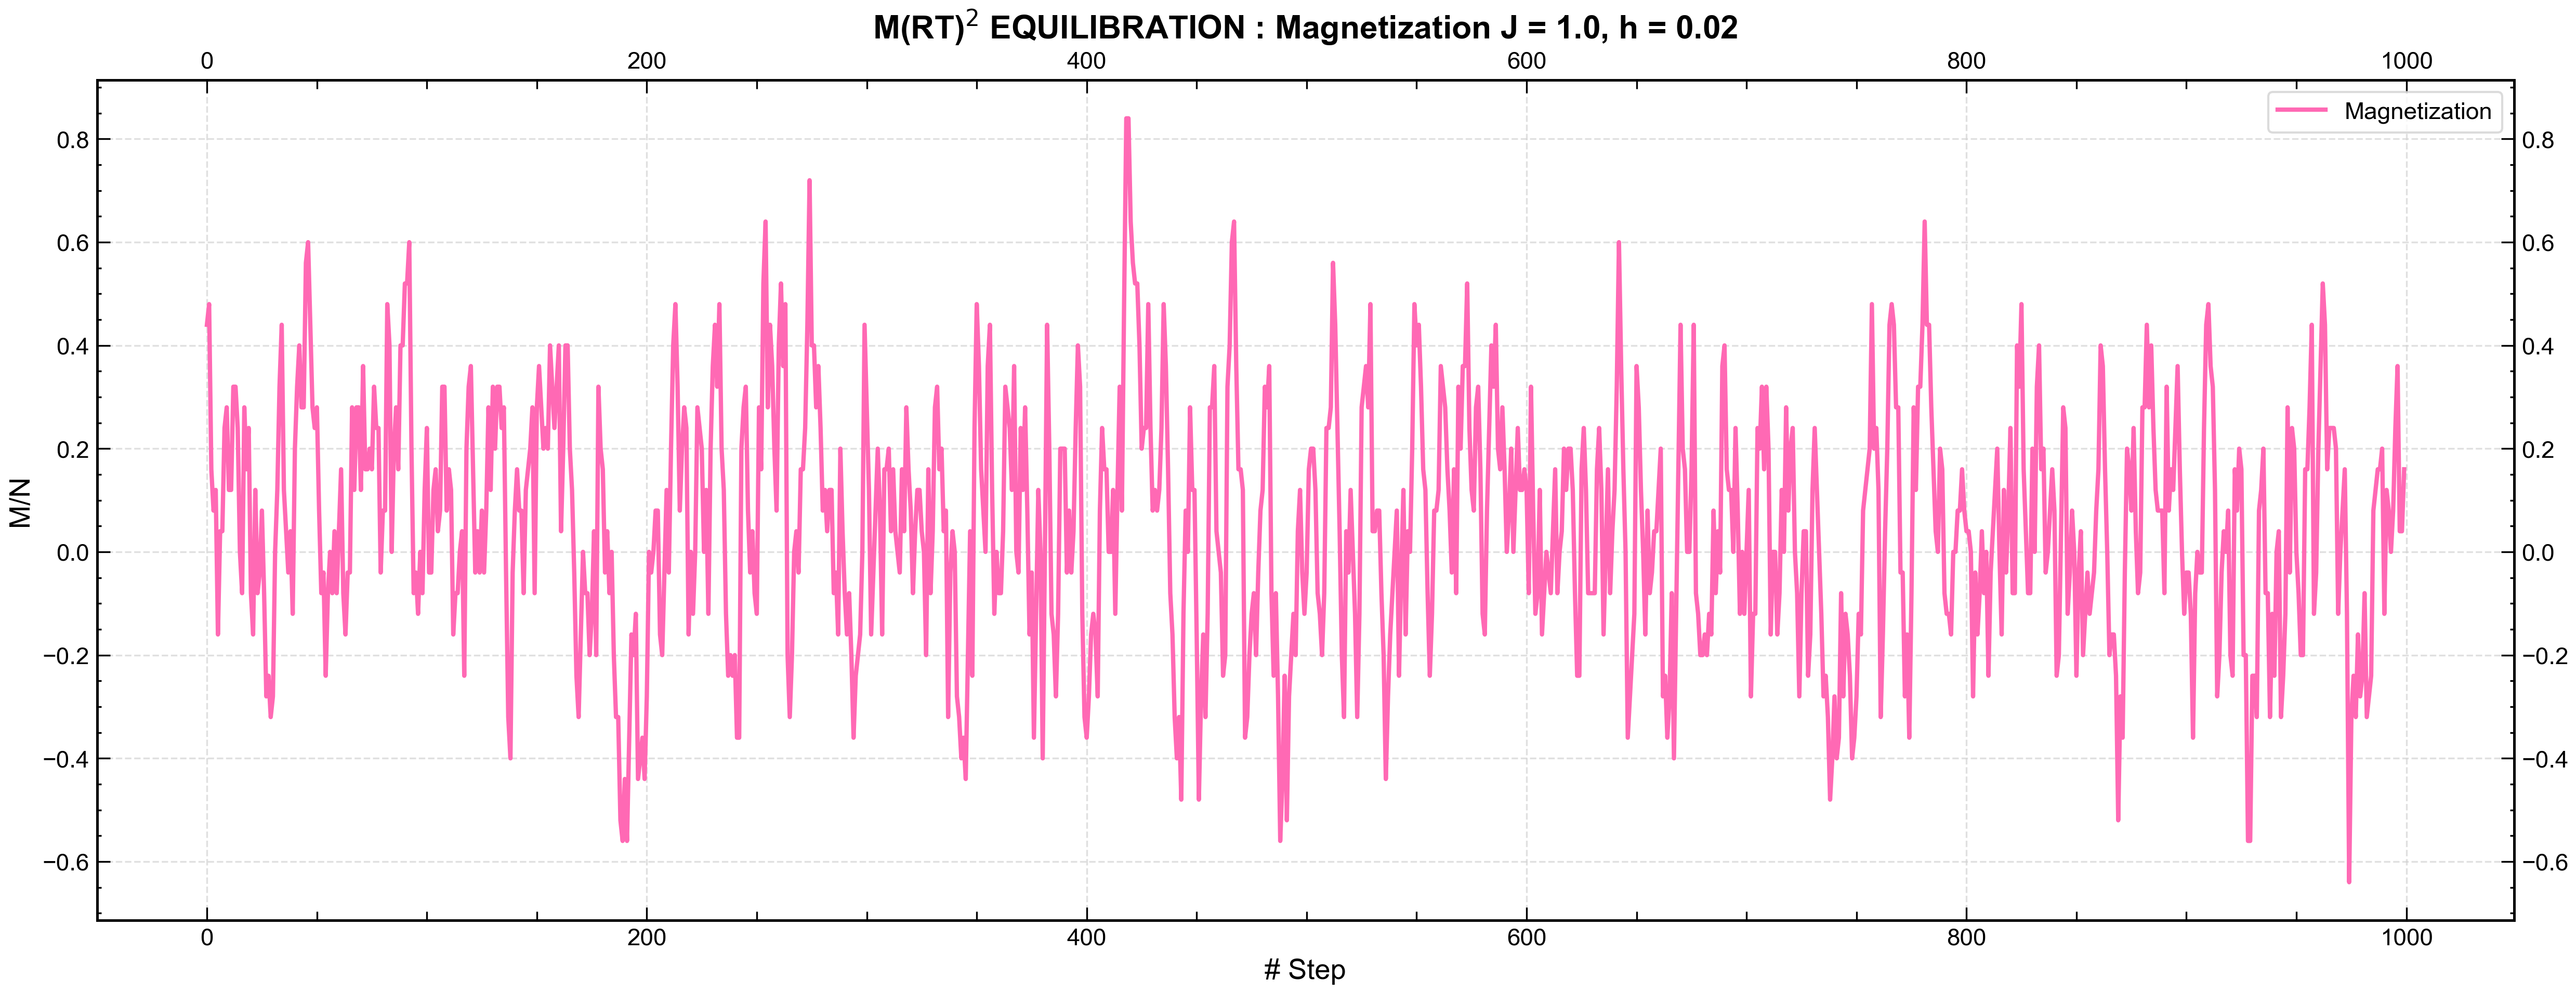

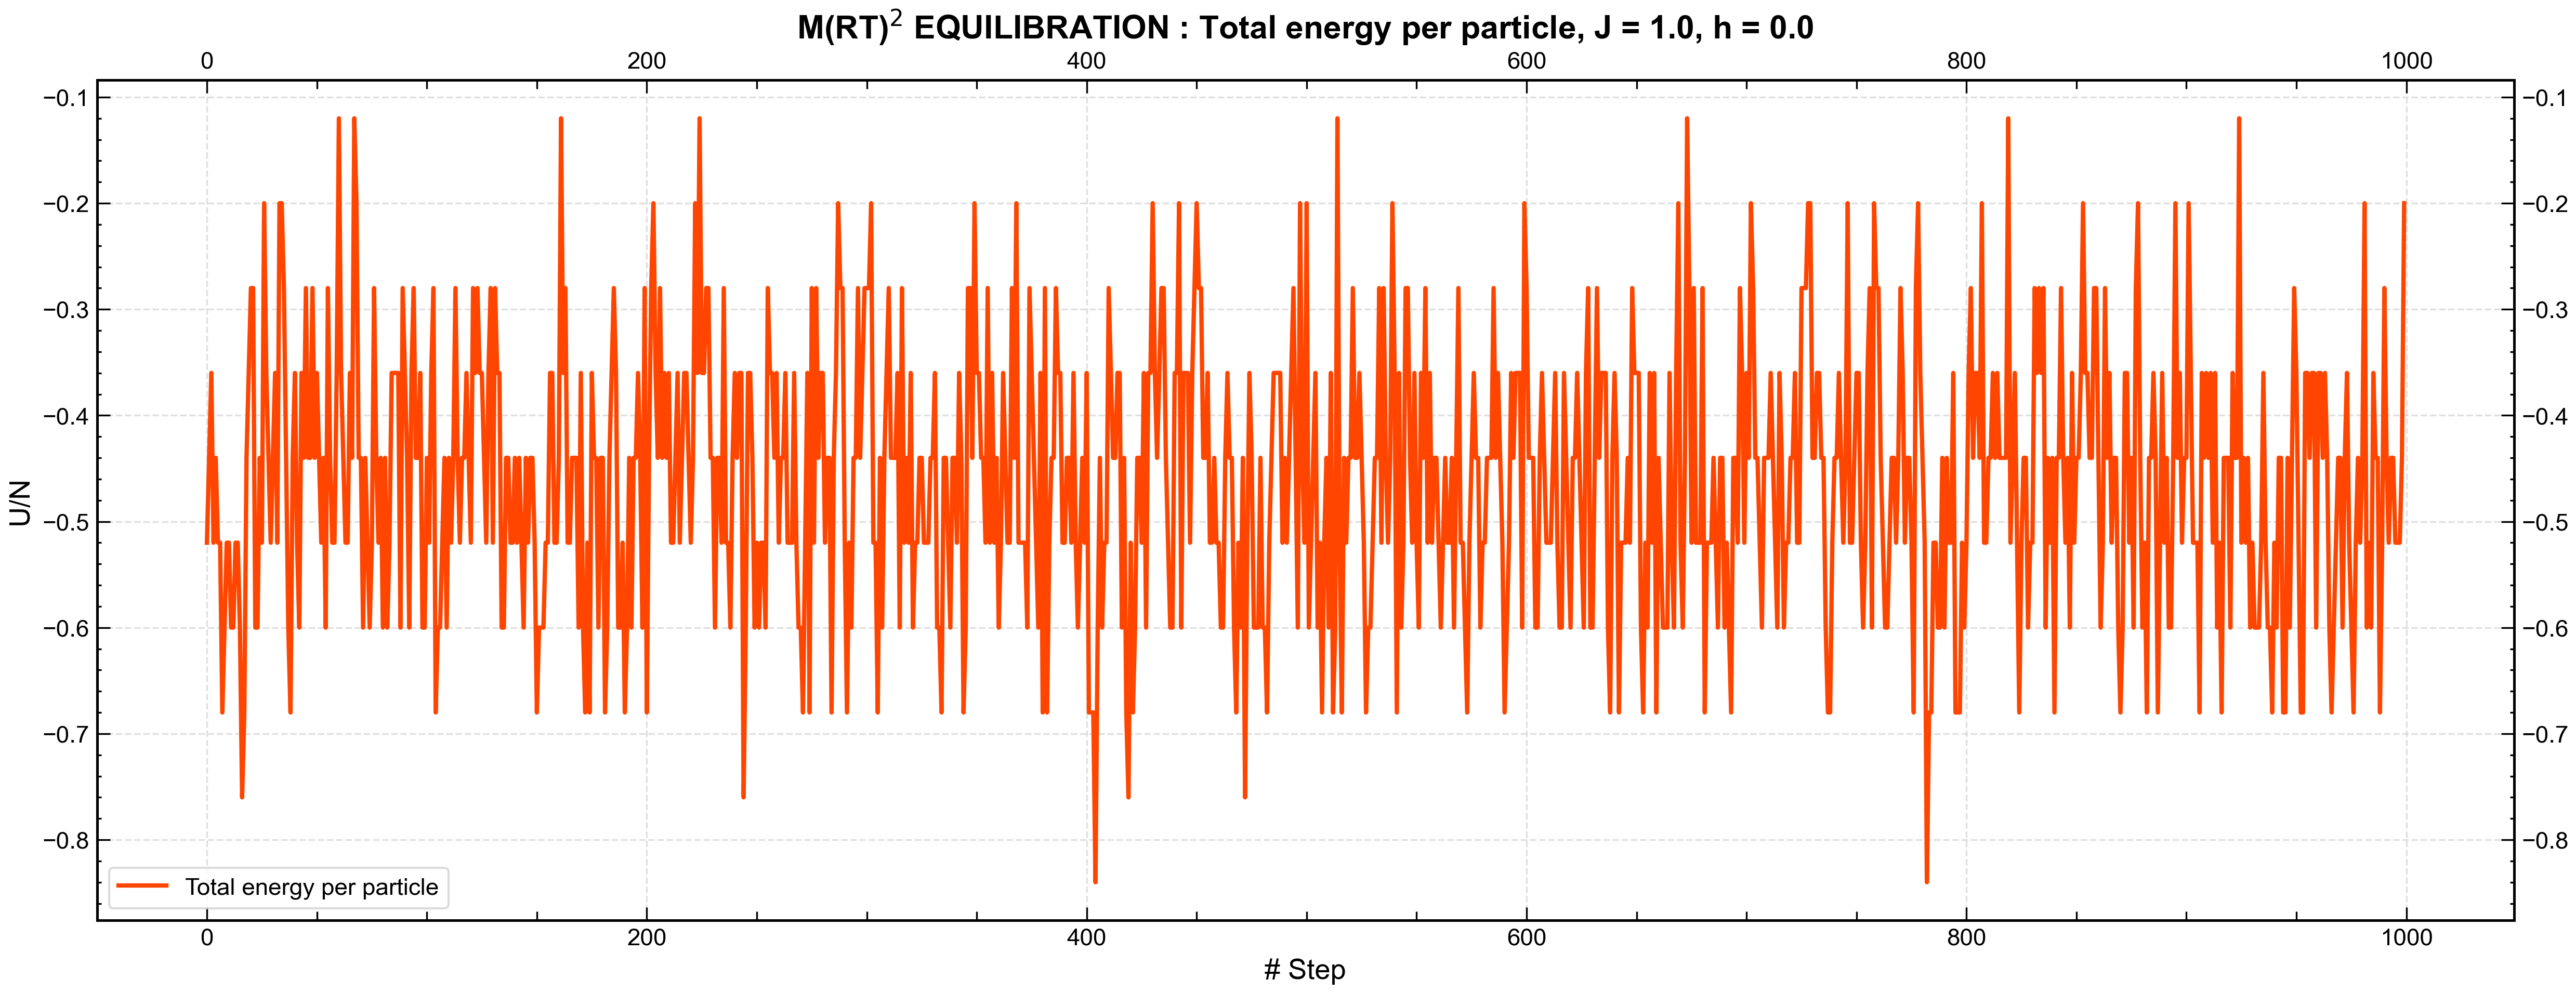

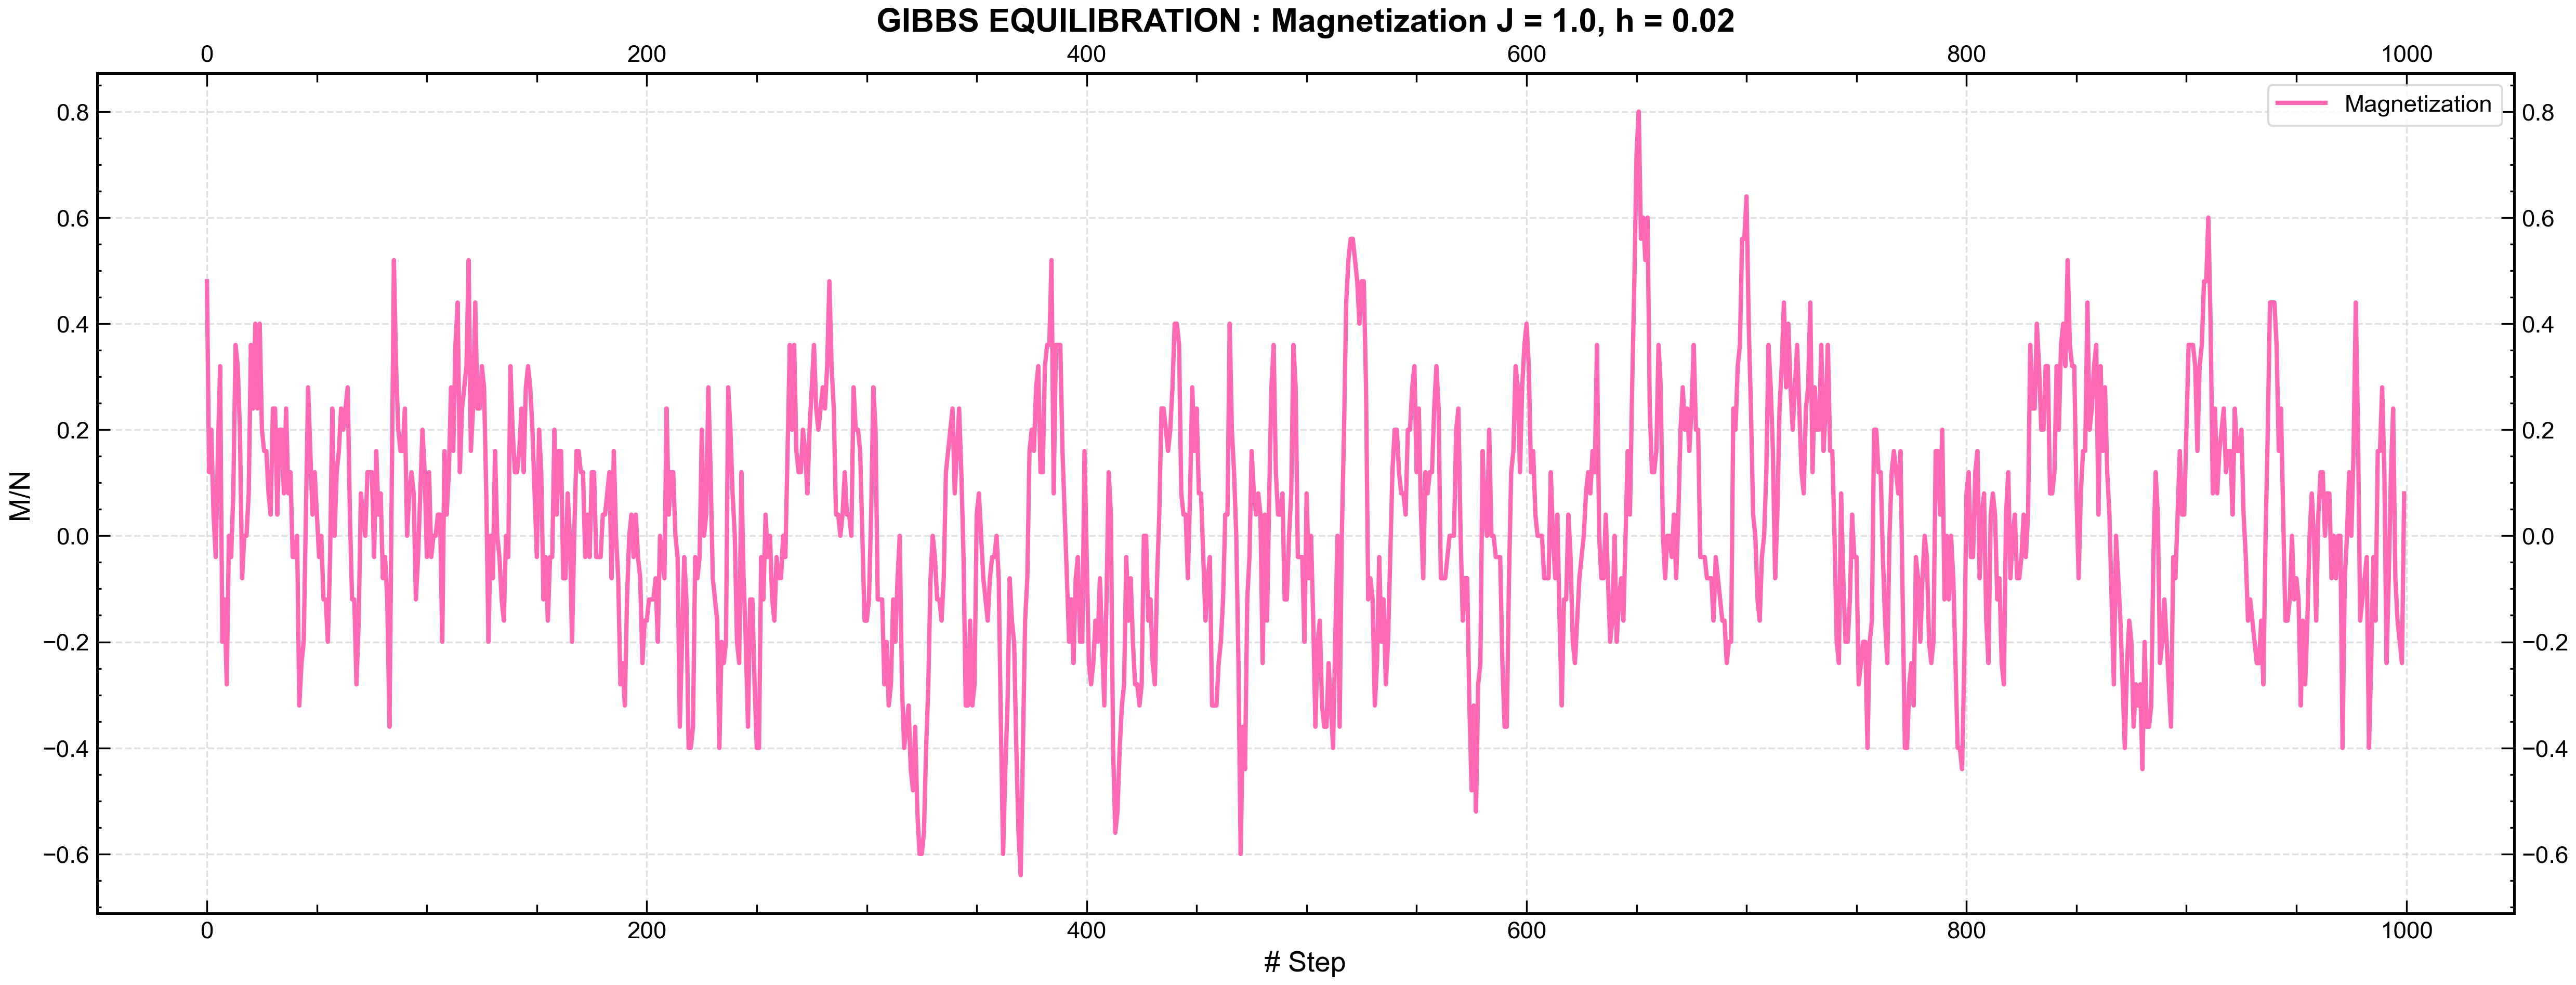

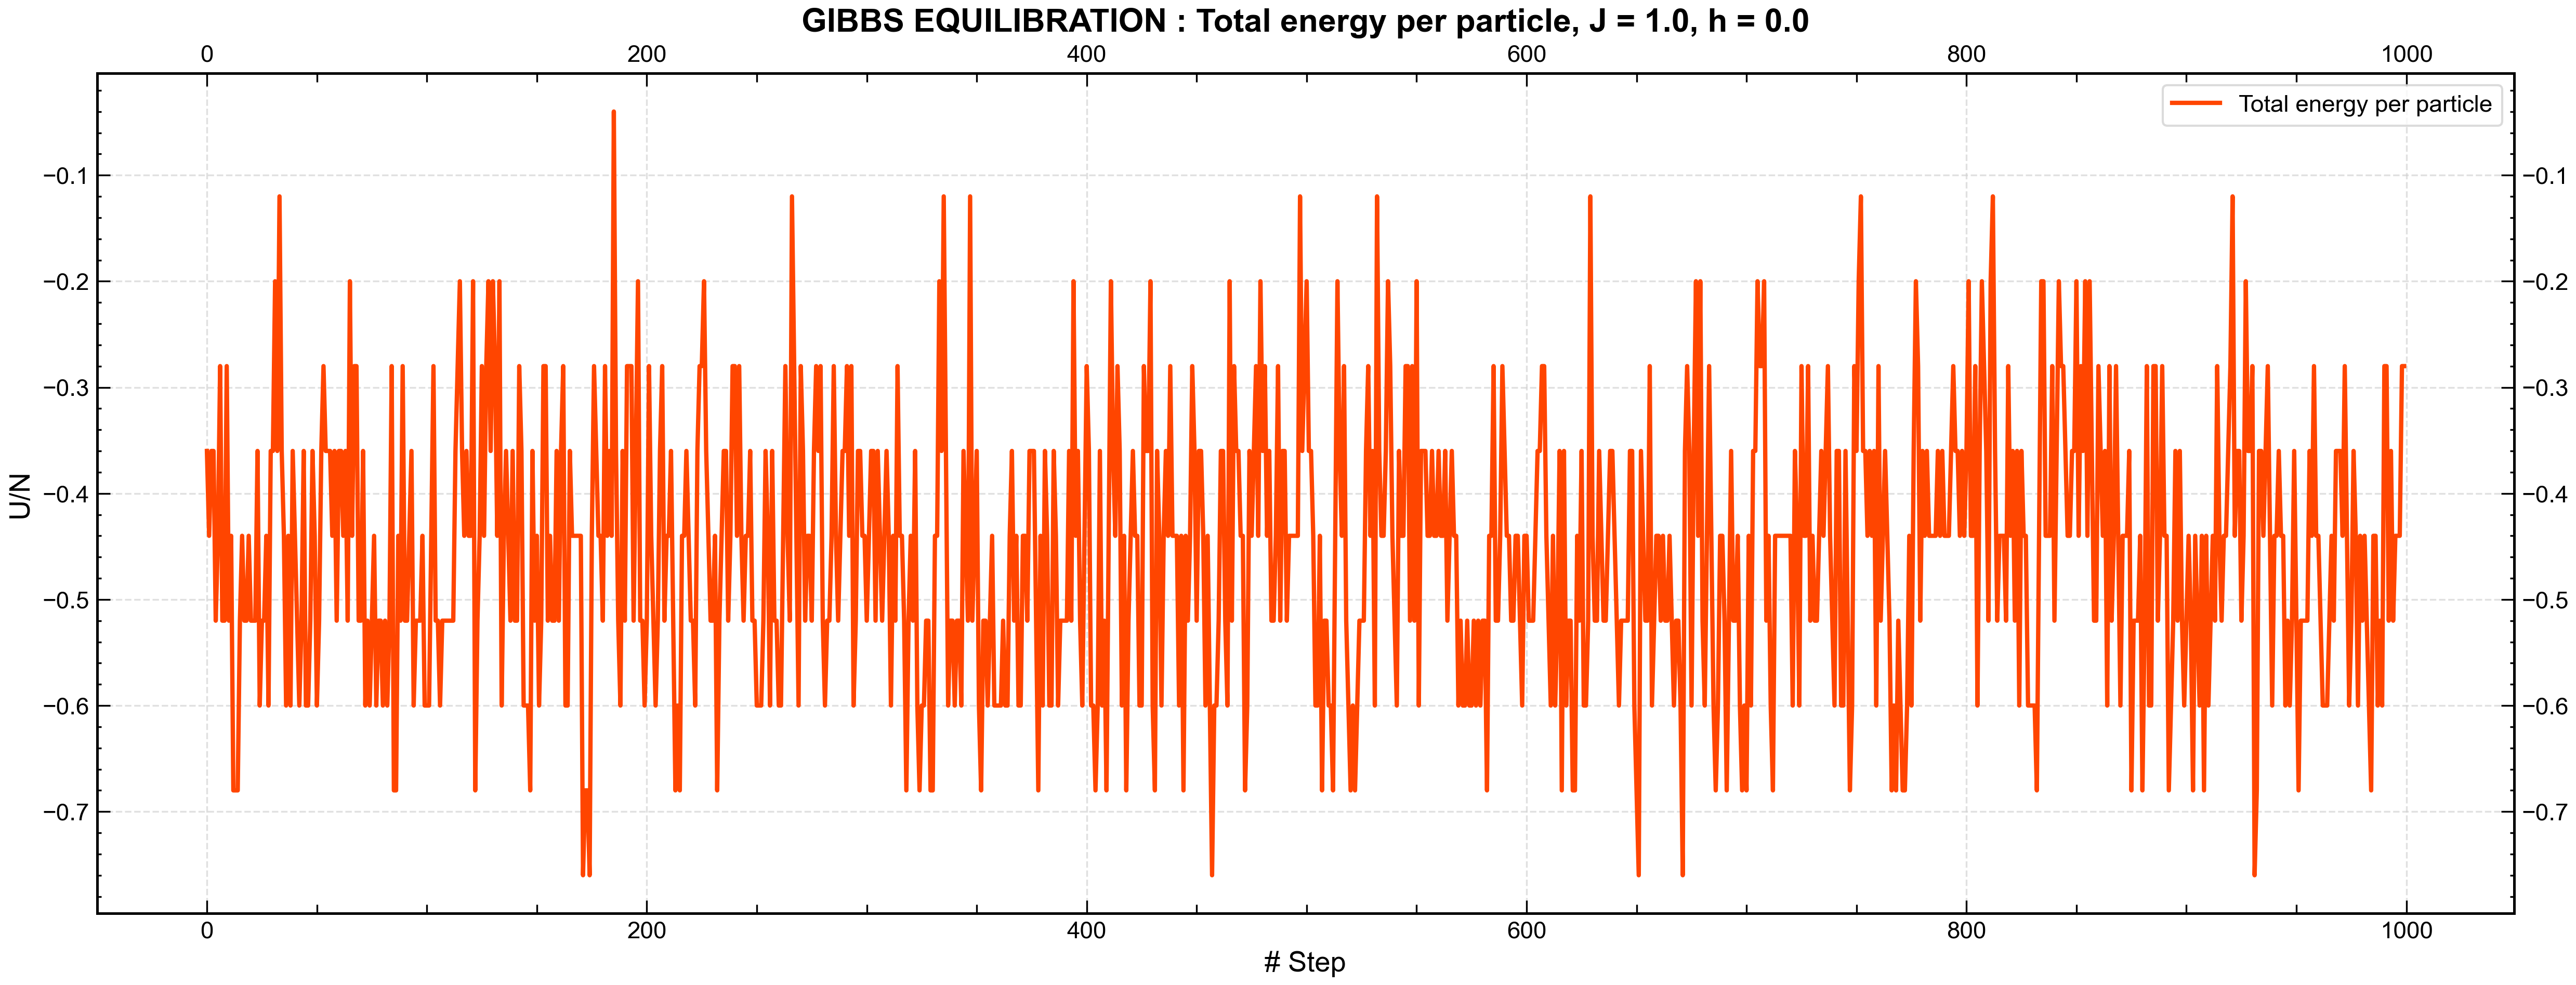

In [49]:
# Equilibration step list
step = np.arange(0, n_step_equil)

first_index = 0
last_index = 1000

# Path to equilibration output files
path_to_file_magnet_equilib = [algorithm[0] + "/magnetic_field_on/equilibration/OUTPUT/magnetization_step.dat", algorithm[1] + "/magnetic_field_on/equilibration/OUTPUT/magnetization_step.dat"]
path_to_file_tenergy_equilib = [algorithm[0] + "/magnetic_field_off/equilibration/OUTPUT/total_energy_step.dat", algorithm[1] + "/magnetic_field_off/equilibration/OUTPUT/total_energy_step.dat"]

# Title list
sup_title=[r"M(RT)$^2$ EQUILIBRATION", "GIBBS EQUILIBRATION"]

for i in range(2):
    
    # Data to plot
    magnet = np.loadtxt(path_to_file_magnet_equilib[i], unpack = True)
    tenergy = np.loadtxt(path_to_file_tenergy_equilib[i], unpack = True)

    # Plotting magnetization per simulation step (equilibration with magnetic field on)
    fig = plt.figure(figsize=(20,7))
    plt.title(sup_title[i] + " : Magnetization J = " + str(J) + ", h = " + str(h_on))
    plt.plot(step[first_index:last_index], magnet[first_index:last_index], color = "hotpink", label = "Magnetization")
    plt.xlabel("# Step")
    plt.ylabel("M/N")
    # plt.grid(True)
    plt.legend()
    # Saving plot in plot archive
    plt.savefig(algorithm[i] + "/magnetic_field_on/equilibration/plot/magnetization.png")

    # Plotting total energy per simulation step (equilibration with magnetic field off)
    fig = plt.figure(figsize=(20,7))
    plt.title(sup_title[i] + " : Total energy per particle, J = " + str(J) + ", h = " + str(h_off))
    plt.plot(step[first_index:last_index], tenergy[first_index:last_index], color = "orangered", label = "Total energy per particle")
    plt.xlabel("# Step")
    plt.ylabel("U/N")
    # plt.grid(True)
    plt.legend()
    # Saving plot in plot archive
    plt.savefig(algorithm[i] + "/magnetic_field_off/equilibration/plot/total_energy_equilibration.png")

plt.show()



<h4>Conclusion</h4>

In all four scenarios the system exhibits extremely rapid thermalization. The time-series data for both $U/N$ and $M/N$ do not display a discernible transient period (an initial drift towards the stationary mean). Instead, the observables immediately begin to fluctuate around their respective equilibrium values from the very first Monte Carlo (MC) step. This confirms that the system has quickly reached a configuration compatible with the target temperature ($T=2.0$). This behavior validates the initial assumption that, due to the large number of single-spin flips performed per MC step (equal to the total number of sites, $N=50$), the initial state (whether random or ordered) is quickly forgotten.

Both the Metropolis and Gibbs sampling algorithms demonstrate comparable efficiency in achieving equilibrium within the first few steps, suggesting that either algorithm is suitable for this particular simulation setup.

<h3><span style="color:darkviolet">Simulations</span></h3>

The figure below provides a direct comparison of the thermodynamic observables calculated using the **Metropolis and Gibbs sampling algorithms** against their known analytical solutions. Since both methods are designed to generate configurations that adhere to the same Boltzmann weight distribution, the statistical results obtained from both schemes are expected to be in strong agreement.

The parameters used for the simulation phase are summarized in the table below.


**NB**: `TEMP` has to be consecutively $2.0 \rightarrow 1.8 \rightarrow 1.6 \rightarrow 1.4 \rightarrow 1.2 \rightarrow 1.0 \rightarrow 0.8 \rightarrow 0.6 \rightarrow 0.5 \rightarrow 0.4 \rightarrow 0.3$.

<div align="center">

| Parameters | Metropolis field on values | Metropolis field off values | Gibbs field on values | Gibbs field off values |
| :--- | :--- | :--- | :--- | :--- |
| SIMULATION_TYPE | 2 1.0 0.02 | 2 1.0 0.0 | 3 1.0 0.02 | 3 1.0 0.0 |
| RESTART | 1 | 1 | 1 | 1 |
| TEMP | ## | ## | ## | ## |
| NPART | 50 | 50 | 50 | 50 |
| RHO | 1.0 | 1.0 | 1.0 | 1.0 | 
| R_CUT | 0.0 | 0.0 | 0.0 | 0.0 | 
| DELTA | 0.0 | 0.0 | 0.0 | 0.0 |
| NBLOCKS | 20 | 20 | 20 | 20 |
| NSTEPS | 20000 | 20000 | 20000 | 20000 |

</div>

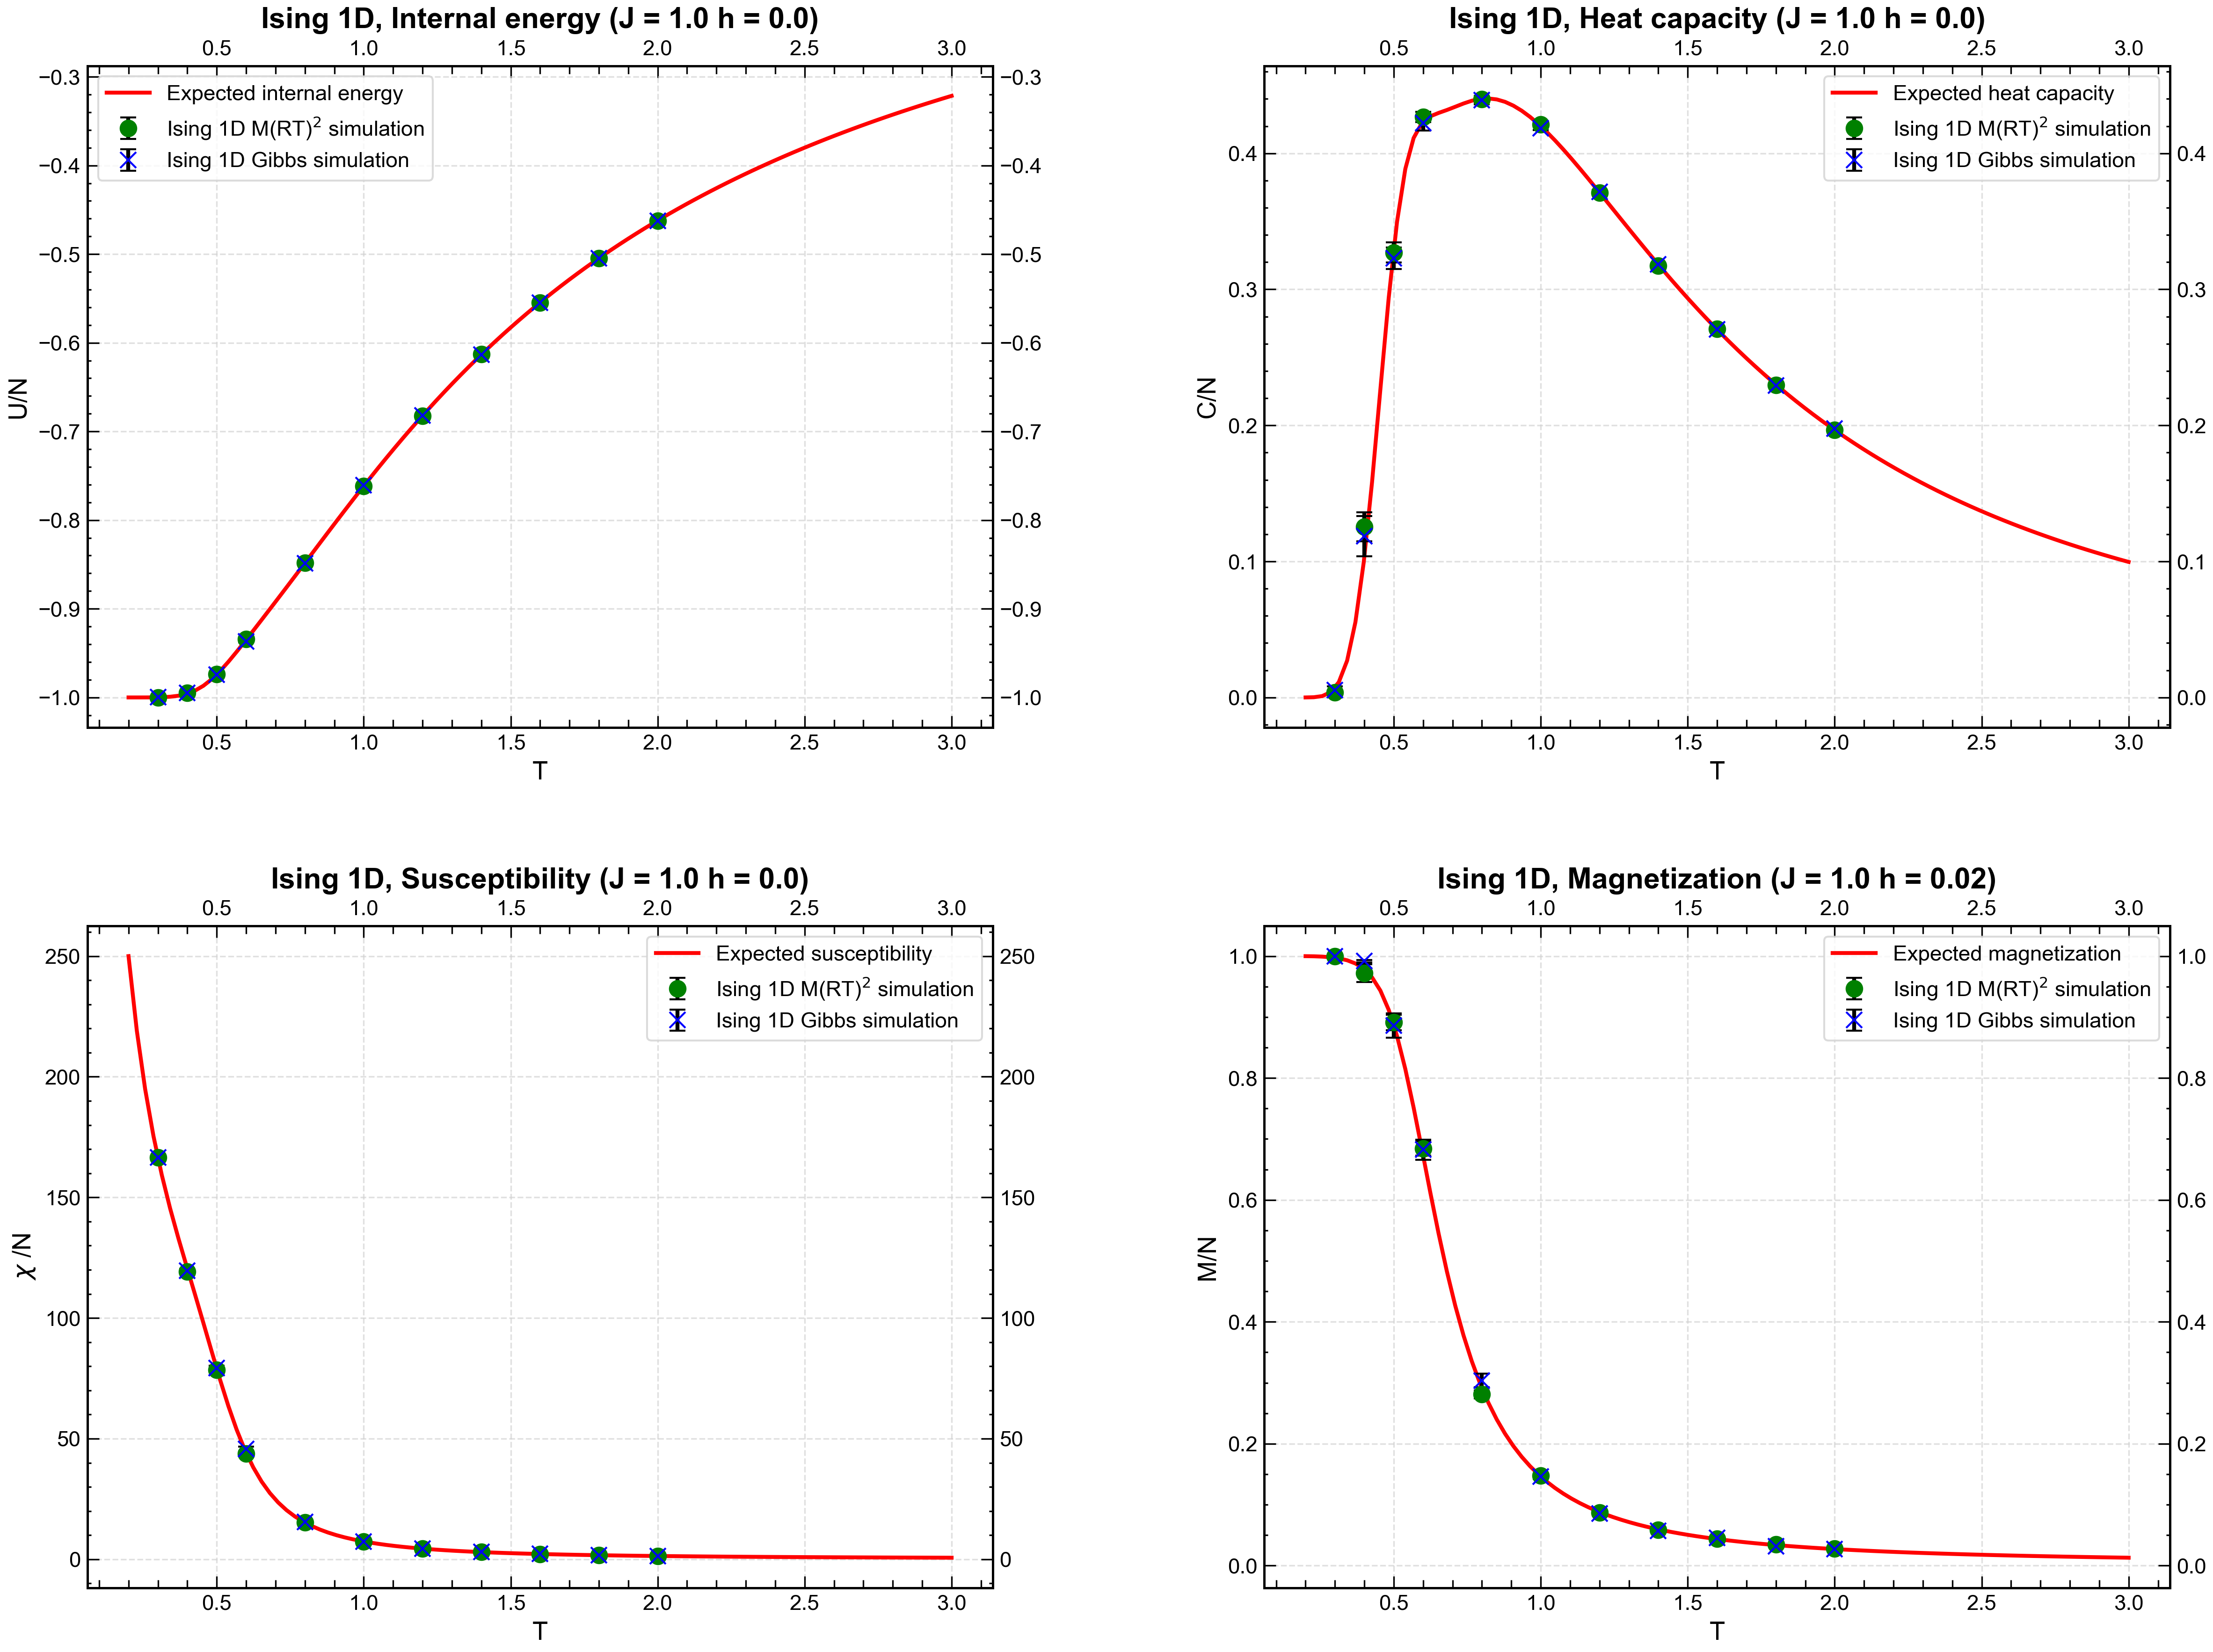

In [50]:

blocks = np.arange(1, n_block_sim + 1)


TENERGY_METRO = np.zeros(11)
TENERGY_GIBBS = np.zeros(11)
ERROR_T_METRO = np.zeros(11)
ERROR_T_GIBBS = np.zeros(11)

CV_METRO = np.zeros(11)
CV_GIBBS = np.zeros(11)
ERROR_CV_METRO = np.zeros(11)
ERROR_CV_GIBBS = np.zeros(11)

CHI_METRO = np.zeros(11)
CHI_GIBBS = np.zeros(11)
ERROR_CHI_METRO = np.zeros(11)
ERROR_CHI_GIBBS = np.zeros(11)

MAGNET_METRO = np.zeros(11)
MAGNET_GIBBS = np.zeros(11)
ERROR_M_METRO = np.zeros(11)
ERROR_M_GIBBS = np.zeros(11)

for i in range(len(T)) :

    tenergy_metro, error_t_metro = np.loadtxt(algorithm[0] + "/magnetic_field_off/T_" + str(T[i]) + "/OUTPUT/total_energy.dat", usecols = (2, 3), unpack = True)
    tenergy_gibbs, error_t_gibbs = np.loadtxt(algorithm[1] + "/magnetic_field_off/T_" + str(T[i]) + "/OUTPUT/total_energy.dat", usecols = (2, 3), unpack = True)

    cv_metro, error_cv_metro = np.loadtxt(algorithm[0] + "/magnetic_field_off/T_" + str(T[i]) + "/OUTPUT/specific_heat.dat", usecols = (2, 3), unpack = True)
    cv_gibbs, error_cv_gibbs = np.loadtxt(algorithm[1] + "/magnetic_field_off/T_" + str(T[i]) + "/OUTPUT/specific_heat.dat", usecols = (2, 3), unpack = True)

    chi_metro, error_chi_metro = np.loadtxt(algorithm[0] + "/magnetic_field_off/T_" + str(T[i]) + "/OUTPUT/susceptibility.dat", usecols = (2, 3), unpack = True)
    chi_gibbs, error_chi_gibbs = np.loadtxt(algorithm[1] + "/magnetic_field_off/T_" + str(T[i]) + "/OUTPUT/susceptibility.dat", usecols = (2, 3), unpack = True)

    magnet_metro, error_m_metro = np.loadtxt(algorithm[0] + "/magnetic_field_on/T_" + str(T[i]) + "/OUTPUT/magnetization.dat", usecols = (2, 3), unpack = True)
    magnet_gibbs, error_m_gibbs = np.loadtxt(algorithm[1] + "/magnetic_field_on/T_" + str(T[i]) + "/OUTPUT/magnetization.dat", usecols = (2, 3), unpack = True)

    TENERGY_METRO[i] = tenergy_metro[-1]
    ERROR_T_METRO[i] = error_t_metro[-1]
    TENERGY_GIBBS[i] = tenergy_gibbs[-1]
    ERROR_T_GIBBS[i] = error_t_gibbs[-1]

    CV_METRO[i] = cv_metro[-1]
    CV_GIBBS[i] = cv_gibbs[-1]
    ERROR_CV_METRO[i] = error_cv_metro[-1]
    ERROR_CV_GIBBS[i] = error_cv_gibbs[-1]

    CHI_METRO[i] = chi_metro[-1]
    CHI_GIBBS[i] = chi_gibbs[-1]
    ERROR_CHI_METRO[i] = error_chi_metro[-1]
    ERROR_CHI_GIBBS[i] = error_chi_gibbs[-1]

    MAGNET_METRO[i] = magnet_metro[-1]
    MAGNET_GIBBS[i] = magnet_gibbs[-1]
    ERROR_M_METRO[i] = error_m_metro[-1]
    ERROR_M_GIBBS[i] = error_m_gibbs[-1]

fig, axs = plt.subplots(2, 2, figsize=(16, 12))

# Internal energy
th = np.tanh(J/t)
thN= th**N
ch = 1/th
e = -J*( th + ch*thN )/( 1 + thN )

axs[0][0].set_title('Ising 1D, Internal energy (J = ' + str(J) + ' h = '+ str(h_off) + ')')
axs[0][0].plot(t, e, color = "red", label = "Expected internal energy")
axs[0][0].errorbar(T, TENERGY_METRO, yerr = ERROR_T_METRO, linestyle = "none", ecolor = "black", color = "green", markersize = 8, capsize = 4, label = r"Ising 1D M(RT)$^2$ simulation", marker = "o")
axs[0][0].errorbar(T, TENERGY_GIBBS, yerr = ERROR_T_GIBBS, linestyle = "none", ecolor = "black", color = "blue", markersize = 8, capsize = 4, label = "Ising 1D Gibbs simulation", marker = "x")
axs[0][0].set_xlabel('T')
axs[0][0].set_ylabel('U/N')
# axs[0][0].grid(True)
axs[0][0].legend()

# Specific heat
heat=((beta*J)**2)*(((1+thN+(N-1)*(th**2)+(N-1)*(ch**2)*thN)/(1+thN))-N*((th+ch*thN)/(1+thN))**2)

axs[0][1].set_title('Ising 1D, Heat capacity (J = ' + str(J) + ' h = '+ str(h_off) + ')')
axs[0][1].plot(t, heat, color = "red", label = "Expected heat capacity")
axs[0][1].errorbar(T, CV_METRO, yerr = ERROR_CV_METRO, linestyle = "none", ecolor = "black", color = "green", markersize = 8, capsize = 4, label = r"Ising 1D M(RT)$^2$ simulation", marker = "o")
axs[0][1].errorbar(T, CV_GIBBS, yerr = ERROR_CV_GIBBS, linestyle = "none", ecolor = "black", color = "blue", markersize = 8, capsize = 4, label = "Ising 1D Gibbs simulation", marker = "x")
axs[0][1].set_xlabel('T')
axs[0][1].set_ylabel('C/N')
# axs[0][1].grid(True)
axs[0][1].legend()

# Susceptibility
X = beta*np.exp(2*beta*J)*(1-thN)/(1+thN)

axs[1][0].set_title('Ising 1D, Susceptibility (J = ' + str(J) + ' h = '+ str(h_off) + ')')
axs[1][0].plot(t, X, color = "red", label = "Expected susceptibility")
axs[1][0].errorbar(T, CHI_METRO, yerr = ERROR_CHI_METRO, linestyle = "none", ecolor = "black", color = "green", markersize = 8, capsize = 4, label = r"Ising 1D M(RT)$^2$ simulation", marker = "o")
axs[1][0].errorbar(T, CHI_GIBBS, yerr = ERROR_CHI_GIBBS, linestyle = "none", ecolor = "black", color = "blue", markersize = 8, capsize = 4, label = "Ising 1D Gibbs simulation", marker = "x")
axs[1][0].set_xlabel('T')
axs[1][0].set_ylabel(r'$\chi$ /N')
# axs[1][0].grid(True)
axs[1][0].legend()

# Magnetization
l1 = np.exp(beta*J)*np.cosh(beta*h_on)+np.sqrt(np.exp(2*beta*J)*np.cosh(beta*h_on)*np.cosh(beta*h_on)-2*np.sinh(2*beta*J))
l2 = np.exp(beta*J)*np.cosh(beta*h_on)-np.sqrt(np.exp(2*beta*J)*np.cosh(beta*h_on)*np.cosh(beta*h_on)-2*np.sinh(2*beta*J))
Z = l1**N + l2**N
M = (np.exp(beta*J)*np.sinh(beta*h_on)*((l1**(N-1))*(1+np.exp(beta*J)*np.cosh(beta*h_on)/np.sqrt(np.exp(2*beta*J)*np.cosh(beta*h_on)*np.cosh(beta*h_on)-2*np.sinh(2*beta*J))) 
        + (l2**(N-1))*(1-np.exp(beta*J)*np.cosh(beta*h_on)/np.sqrt(np.exp(2*beta*J)*np.cosh(beta*h_on)*np.cosh(beta*h_on)-2*np.sinh(2*beta*J)))))/(Z)

axs[1][1].set_title('Ising 1D, Magnetization (J = ' + str(J) + ' h = '+ str(h_on) + ')')
axs[1][1].plot(t, M, color = "red", label = "Expected magnetization")
axs[1][1].errorbar(T, MAGNET_METRO, yerr = ERROR_M_METRO, linestyle = "none", ecolor = "black", color = "green", markersize = 8, capsize = 4, label = r"Ising 1D M(RT)$^2$ simulation", marker = "o")
axs[1][1].errorbar(T, MAGNET_GIBBS, yerr = ERROR_M_GIBBS, linestyle = "none", ecolor = "black", color = "blue", markersize = 8, capsize = 4, label = "Ising 1D Gibbs simulation", marker = "x")
axs[1][1].set_xlabel('T')
axs[1][1].set_ylabel('M/N')
# axs[1][1].grid(True)
axs[1][1].legend()

plt.tight_layout()
plt.subplots_adjust(
    wspace=0.3,  # Spazio orizzontale
    hspace=0.3, # Spazio verticale
    # top=0.92     # move below plots (gives space to suptitle)
    )

plt.savefig("plot/observables.png")

plt.show()

<h4>Conclusion</h4>

The results validate the numerical approach by reproducing the known analytical behavior of the one-dimensional system. Crucially, the data points obtained from the simulation, when accounting for their associated statistical error bars, are found to be **statistically in agreement with the exact theoretical values**. This verifies the correct implementation of the sampling method.

In summary, the simulation successfully demonstrates the smooth, analytic behavior of the 1D Ising model, confirming that thermal fluctuations are always sufficient to prevent long-range magnetic order above absolute zero. Most importantly, the results confirm that both the **Gibbs** and **M(RT)$^2$** algorithms reliably reproduce the expected theoretical data.